In [3]:
import hdc
hdc.connect()

Database is already connected.


In [4]:
prov_c = '49' ;
start_d1 = '2024-10-01' ; 
end_d1 = '2025-09-30' ; 
start_d2 = '2025-10-01' ; 
end_d2 = '2026-09-30'

In [3]:
%%sql
/* -- Telemedicine รายหน่วยบริการ-- */
DROP TABLE IF EXISTS telemed_hosp ;
CREATE TABLE telemed_hosp
AS
SELECT c.amp_code,c.amp_name
    ,c.hoscode AS hospcode,c.hosname AS hospname
    ,c1.hostypecode,c1.hostypename
    ,c.mcode,c.m_name,c.dep_name
    ,x.ServiceAll,x.OPAll,x.TelemedAll
    ,x.Service68,x.OP68,x.Telemed68
    ,x.Service69,x.OP69,x.Telemed69
    ,round((x.Telemed69 / x.OP68 * 100),2) AS PercentTelemed69PerOP68
FROM (
    SELECT s.hospcode
        ,count(DISTINCT CONCAT(s.hospcode,'-',s.pid,'-',s.seq)) AS ServiceAll
        ,count(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Service68
        ,count(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Service69
    
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OPAll
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OP68
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OP69      
    
        ,count(DISTINCT IF(s.typein IN('5'),CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedAll 
        ,count(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Telemed68
        ,count(DISTINCT IF(s.typein IN('5') AND i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedOP68
        ,count(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Telemed69
        ,count(DISTINCT IF(s.typein IN('5') AND i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedOP69     
    FROM service s
        INNER JOIN person p ON s.hospcode=p.hospcode AND s.pid=p.pid
        INNER JOIN diagnosis_opd d ON s.hospcode=d.hospcode AND s.pid=d.pid AND s.seq=d.seq AND s.date_serv=d.date_serv
        LEFT JOIN icd10_chk_op i ON i.d_code=d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
    ) AS x 
    INNER JOIN chospital c ON c.hoscode=x.hospcode 
    LEFT JOIN chostype c1 ON c1.hostypecode=c.hostype 
ORDER BY  c.amp_code,c.hoscode  ;


Count
86


In [5]:
%%sql
/* -- sql ปรับใหม่ จ.มุกดาหาร Telemedicine รายหน่วยบริการ-- */
DROP TABLE IF EXISTS telemed_hosp ;
CREATE TABLE telemed_hosp
AS
SELECT c.amp_code,c.amp_name
    ,c.hoscode AS hospcode,c.hosname AS hospname
    ,c1.hostypecode,c1.hostypename
    ,c.mcode,c.m_name,c.dep_name
    ,x.ServiceAll,x.OPAll,x.TelemedAll
    ,x.Service68,x.OP68,x.Telemed68
    ,x.Service69,x.OP69,x.Telemed69
    ,round((x.Telemed69 / x.OP68 * 100),2) AS PercentTelemed69PerOP68
FROM (
    SELECT s.hospcode
        ,count(DISTINCT CONCAT(s.hospcode,'-',s.pid,'-',s.seq)) AS ServiceAll
        ,count(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Service68
        ,count(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Service69
    
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OPAll
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OP68
        ,count(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS OP69      
    
        ,count(DISTINCT IF(s.typein IN('5'),CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedAll
        ,count(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Telemed68
        ,count(DISTINCT IF(s.typein IN('5') AND i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedOP68
        ,count(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS Telemed69
        ,count(DISTINCT IF(s.typein IN('5') AND i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}',CONCAT(s.hospcode,'-',s.pid,'-',s.seq),NULL)) AS TelemedOP69     
    FROM service s
        LEFT JOIN person p ON s.hospcode=p.hospcode AND s.pid=p.pid
        LEFT JOIN diagnosis_opd d ON s.hospcode=d.hospcode AND s.pid=d.pid AND s.seq=d.seq AND s.date_serv=d.date_serv
        LEFT JOIN icd10_chk_op i ON i.d_code=d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
    ) AS x 
    INNER JOIN chospital c ON c.hoscode=x.hospcode 
    LEFT JOIN chostype c1 ON c1.hostypecode=c.hostype 
ORDER BY  c.amp_code,c.hoscode  ;


Count
86


In [6]:
import os
# This creates the 'Export' folder if it doesn't exist
if not os.path.exists('Export'):
    os.makedirs('Export')
    print("Folder 'Export' created successfully!")
else:
    print("Folder already exists.")

Folder already exists.


In [7]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp.xlsx'

In [8]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [9]:
%%sql
/* -- SQL รายงาน Telemedicine และการรับบริการแยกตาม Typein 2, 3, 5 จ.มุกดาหาร -- */
DROP TABLE IF EXISTS telemed_hosp_235;
CREATE TABLE telemed_hosp_235 AS
SELECT 
    c.amp_code, c.amp_name,
    c.hoscode AS hospcode, c.hosname AS hospname,
    c1.hostypecode, c1.hostypename,
    c.mcode, c.m_name, c.dep_name,
    
    -- ข้อมูลรวมทุกประเภท --
    x.ServiceAll, x.OPAll,
    
    -- ข้อมูลปี 68 แยกตาม Typein --
    x.Type2_68, x.Type3_68, x.Type5_68,
    x.OP68,
    
    -- ข้อมูลปี 69 แยกตาม Typein --
    x.Type2_69, x.Type3_69, x.Type5_69,
    x.OP69,
    
    -- การคำนวณร้อยละ (ตัวอย่าง: เทียบ Telemed ปี 69 กับ OP รวมปี 68) --
    ROUND((x.Type5_69 / x.OP68 * 100), 2) AS PercentTelemed69PerOP68

FROM (
    SELECT 
        s.hospcode,
        -- นับบริการทั้งหมด --
        COUNT(DISTINCT CONCAT(s.hospcode,'-',s.pid,'-',s.seq)) AS ServiceAll,
        
        -- กรองเฉพาะ OP (ตามรหัส icd10 ที่ valid) --
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OPAll,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP68,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP69,
        
        -- แยกตาม Typein ปี 68 (Period 1) --
        COUNT(DISTINCT IF(s.typein = '2' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type2_68,
        COUNT(DISTINCT IF(s.typein = '3' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type3_68,
        COUNT(DISTINCT IF(s.typein = '5' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type5_68,
        
        -- แยกตาม Typein ปี 69 (Period 2) --
        COUNT(DISTINCT IF(s.typein = '2' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type2_69,
        COUNT(DISTINCT IF(s.typein = '3' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type3_69,
        COUNT(DISTINCT IF(s.typein = '5' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Type5_69

    FROM service s
    LEFT JOIN person p ON s.hospcode = p.hospcode AND s.pid = p.pid
    LEFT JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv
    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
86


In [10]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_235.xlsx'

In [11]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_235 ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [11]:
%%sql
/* -- SQL รายงานแยกประเภทการรับบริการ (typein 1-5) 
คำอธิบายเพิ่มเติมเกี่ยวกับ Typein:
Type 1: มารับบริการเอง (Walk-in)
Type 2: มีการนัดหมายไว้ หรือถูกส่งต่อมา (Appointment/Refer)
Type 3: บริการเชิงรุก (เช่น หน่วยแพทย์เคลื่อนที่ หรือคัดกรองในชุมชน)
Type 4: การให้บริการที่บ้าน (Home Visit)
Type 5: การแพทย์ทางไกล (Telemedicine)
จ.มุกดาหาร -- */
DROP TABLE IF EXISTS telemed_hosp_all;
CREATE TABLE telemed_hosp_all AS
SELECT 
    c.amp_code, c.amp_name,
    c.hoscode AS hospcode, c.hosname AS hospname,
    c1.hostypecode, c1.hostypename,
    
    -- ข้อมูลรวม (ทุกประเภท) --
    x.Service68, x.OP68,
    x.Service69, x.OP69,

    -- ปี 2568: แยกตาม Typein 1-5 --
    x.T1_68 AS Type1_68_WalkIn,
    x.T2_68 AS Type2_68_Appointment,
    x.T3_68 AS Type3_68_Community,
    x.T4_68 AS Type4_68_Home,
    x.T5_68 AS Type5_68_Telemed,

    -- ปี 2569: แยกตาม Typein 1-5 --
    x.T1_69 AS Type1_69_WalkIn,
    x.T2_69 AS Type2_69_Appointment,
    x.T3_69 AS Type3_69_Community,
    x.T4_69 AS Type4_69_Home,
    x.T5_69 AS Type5_69_Telemed,
    
    -- การคำนวณสัดส่วน Telemed (Type 5) --
    ROUND((x.T5_69 / x.OP68 * 100), 2) AS PercentTelemed69PerOP68

FROM (
    SELECT 
        s.hospcode,
        -- รวม Service ทั้งหมดแยกช่วงเวลา
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service68,
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service69,
        
        -- รวม OP (ตาม Valid ICD10)
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP68,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP69,
        
        -- ปี 68 (Period 1) แยกราย Typein
        COUNT(DISTINCT IF(s.typein='1' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T1_68,
        COUNT(DISTINCT IF(s.typein='2' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T2_68,
        COUNT(DISTINCT IF(s.typein='3' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T3_68,
        COUNT(DISTINCT IF(s.typein='4' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T4_68,
        COUNT(DISTINCT IF(s.typein='5' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T5_68,

        -- ปี 69 (Period 2) แยกราย Typein
        COUNT(DISTINCT IF(s.typein='1' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T1_69,
        COUNT(DISTINCT IF(s.typein='2' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T2_69,
        COUNT(DISTINCT IF(s.typein='3' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T3_69,
        COUNT(DISTINCT IF(s.typein='4' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T4_69,
        COUNT(DISTINCT IF(s.typein='5' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS T5_69

    FROM service s
    LEFT JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv
    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
86


In [12]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_all.xlsx'

In [13]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_all ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [14]:
%%sql
/* -- SQL รายงานนับรายคน โดยตั้งต้นจากแฟ้ม Person (รายหน่วยบริการ) จ.มุกดาหาร -- */
DROP TABLE IF EXISTS telemed_hosp_person;
CREATE TABLE telemed_hosp_person AS
SELECT 
    c.amp_code, c.amp_name,
    c.hoscode AS hospcode, c.hosname AS hospname,
    c1.hostypecode, c1.hostypename,
    
    -- จำนวนคนรวม (ที่มาใช้บริการ) --
    x.PersonAll68, x.OP_Person68,
    x.PersonAll69, x.OP_Person69,

    -- ปี 2568: นับรายคนแยกตาม Typein 1-5 --
    x.P1_68 AS Person_Type1_68,
    x.P2_68 AS Person_Type2_68,
    x.P3_68 AS Person_Type3_68,
    x.P4_68 AS Person_Type4_68,
    x.P5_68 AS Person_Type5_68,

    -- ปี 2569: นับรายคนแยกตาม Typein 1-5 --
    x.P1_69 AS Person_Type1_69,
    x.P2_69 AS Person_Type2_69,
    x.P3_69 AS Person_Type3_69,
    x.P4_69 AS Person_Type4_69,
    x.P5_69 AS Person_Type5_69,
    
    -- การคำนวณสัดส่วนผู้ป่วย Telemed (รายคน) --
    ROUND((x.P5_69 / x.OP_Person68 * 100), 2) AS PercentTelemedPerson69PerOP68

FROM (
    SELECT 
        p.hospcode,
        -- นับรายคนจากแฟ้ม Person ที่ปรากฏใน Service ตามช่วงเวลา
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS PersonAll68,
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS PersonAll69,
        
        -- นับรายคนที่เป็นกลุ่ม OP (Valid ICD10)
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS OP_Person68,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS OP_Person69,
        
        -- ปี 68: แยกตาม Typein (นับจาก ID คน)
        COUNT(DISTINCT IF(s.typein='1' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS P1_68,
        COUNT(DISTINCT IF(s.typein='2' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS P2_68,
        COUNT(DISTINCT IF(s.typein='3' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS P3_68,
        COUNT(DISTINCT IF(s.typein='4' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS P4_68,
        COUNT(DISTINCT IF(s.typein='5' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', p.pid, NULL)) AS P5_68,

        -- ปี 69: แยกตาม Typein (นับจาก ID คน)
        COUNT(DISTINCT IF(s.typein='1' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS P1_69,
        COUNT(DISTINCT IF(s.typein='2' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS P2_69,
        COUNT(DISTINCT IF(s.typein='3' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS P3_69,
        COUNT(DISTINCT IF(s.typein='4' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS P4_69,
        COUNT(DISTINCT IF(s.typein='5' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', p.pid, NULL)) AS P5_69

    FROM person p
    -- ใช้ INNER JOIN เพื่อเลือกเฉพาะคนที่มีข้อมูลการรับบริการจริง
    INNER JOIN service s ON p.hospcode = s.hospcode AND p.pid = s.pid
    LEFT JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv
    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY p.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
86


In [15]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_person.xlsx'

In [16]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_person ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [17]:
%%sql
/* -- SQL ปรับปรุง: แยก 4 กลุ่มโรค (DM, HT, Cancer, Psych) รายหน่วยบริการ -- */
DROP TABLE IF EXISTS telemed_hosp_ncd ;
CREATE TABLE telemed_hosp_ncd
AS
SELECT 
    c.amp_code,
    c.amp_name,
    c.hoscode AS hospcode,
    c.hosname AS hospname,
    c1.hostypecode,
    c1.hostypename,
    -- จำนวนรับบริการแยกกลุ่มโรค (รวมทุกปีที่เลือก)
    x.Visit_DM, x.Tele_DM,
    x.Visit_HT, x.Tele_HT,
    x.Visit_Cancer, x.Tele_Cancer,
    x.Visit_Psych, x.Tele_Psych,
    -- ข้อมูลภาพรวมและตัวชี้วัดปี 68/69
    x.Service68, x.OP68, x.Telemed68,
    x.Service69, x.OP69, x.Telemed69,
    ROUND((x.Telemed69 / x.OP68 * 100), 2) AS PercentTelemed69PerOP68
FROM (
    SELECT 
        s.hospcode,
        -- นับแยกตามกลุ่มโรค (Count Distinct Visit)
        COUNT(DISTINCT IF(LEFT(ch.chronic, 3) BETWEEN 'E10' AND 'E14', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_DM,
        COUNT(DISTINCT IF(LEFT(ch.chronic, 3) BETWEEN 'E10' AND 'E14' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_DM,
        
        COUNT(DISTINCT IF(LEFT(ch.chronic, 3) BETWEEN 'I10' AND 'I15', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_HT,
        COUNT(DISTINCT IF(LEFT(ch.chronic, 3) BETWEEN 'I10' AND 'I15' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_HT,
        
        COUNT(DISTINCT IF(LEFT(ch.chronic, 1) = 'C', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_Cancer,
        COUNT(DISTINCT IF(LEFT(ch.chronic, 1) = 'C' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_Cancer,
        
        COUNT(DISTINCT IF(LEFT(ch.chronic, 1) = 'F', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_Psych,
        COUNT(DISTINCT IF(LEFT(ch.chronic, 1) = 'F' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_Psych,

        -- ข้อมูลปีงบประมาณ 68
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service68,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP68,
        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed68,

        -- ข้อมูลปีงบประมาณ 69
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service69,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP69,
        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed69
        
    FROM service s
    INNER JOIN chronic ch ON s.hospcode = ch.hospcode AND s.pid = ch.pid
    AND (
        LEFT(ch.chronic, 3) BETWEEN 'E10' AND 'E14'
        OR LEFT(ch.chronic, 3) BETWEEN 'I10' AND 'I15'
        OR LEFT(ch.chronic, 1) = 'C'
        OR LEFT(ch.chronic, 1) = 'F'
    )
    LEFT JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv
    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
86


In [18]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_ncd.xlsx'

In [19]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_ncd ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [20]:
%%sql

/* -- SQL ปรับปรุง: Telemedicine กลุ่มแม่และเด็ก (MCH) รายหน่วยบริการ -- */

DROP TABLE IF EXISTS telemed_hosp_mch ;

CREATE TABLE telemed_hosp_mch

AS

SELECT 

    c.amp_code,

    c.amp_name,

    c.hoscode AS hospcode,

    c.hosname AS hospname,

    c1.hostypecode,

    c1.hostypename,

    -- จำนวนรับบริการแยกกลุ่ม MCH

    x.Visit_ANC, x.Tele_ANC,

    x.Visit_PNC, x.Tele_PNC,

    x.Visit_WCC, x.Tele_WCC,

    x.Visit_FP, x.Tele_FP,

    -- ข้อมูลภาพรวมและตัวชี้วัดปี 68/69

    x.Service68, x.OP68, x.Telemed68,

    x.Service69, x.OP69, x.Telemed69,

    ROUND((x.Telemed69 / NULLIF(x.OP68, 0) * 100), 2) AS PercentTelemed69PerOP68

FROM (

    SELECT 

        s.hospcode,

        -- 1. กลุ่มฝากครรภ์ (ANC)

        COUNT(DISTINCT IF(LEFT(d.diagcode, 1) = 'O' OR LEFT(d.diagcode, 3) BETWEEN 'Z32' AND 'Z36', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_ANC,

        COUNT(DISTINCT IF((LEFT(d.diagcode, 1) = 'O' OR LEFT(d.diagcode, 3) BETWEEN 'Z32' AND 'Z36') AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_ANC,

        

        -- 2. กลุ่มหลังคลอด (PNC)

        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) = 'Z39', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_PNC,

        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) = 'Z39' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_PNC,

        

        -- 3. กลุ่มเด็กดี/พัฒนาการ (WCC/Well Child)

        COUNT(DISTINCT IF(d.diagcode IN ('Z001','Z761','Z762'), CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_WCC,

        COUNT(DISTINCT IF(d.diagcode IN ('Z001','Z761','Z762') AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_WCC,

        

        -- 4. กลุ่มวางแผนครอบครัว (Family Planning)

        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) = 'Z30', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_FP,

        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) = 'Z30' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_FP,



        -- ข้อมูลปีงบประมาณ 68

        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service68,

        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP68,

        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed68,



        -- ข้อมูลปีงบประมาณ 69

        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service69,

        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP69,

        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed69

        

    FROM service s

    INNER JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv

    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode

    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'

    /* กรองเฉพาะ Visit ที่เกี่ยวข้องกับ MCH เท่านั้นเพื่อความเร็ว */

    AND (

        LEFT(d.diagcode, 1) = 'O' 

        OR LEFT(d.diagcode, 3) IN ('Z30','Z32','Z33','Z34','Z35','Z36','Z39')

        OR d.diagcode IN ('Z001','Z761','Z762')

    )

    GROUP BY s.hospcode

) AS x 

INNER JOIN chospital c ON c.hoscode = x.hospcode 

LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 

ORDER BY c.amp_code, c.hoscode;

Count
86


In [21]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_mch.xlsx'

In [22]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_mch ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [23]:
%%sql
/* -- SQL ปรับปรุง: Telemedicine กลุ่ม LTC และ Palliative Care รายหน่วยบริการ -- */
DROP TABLE IF EXISTS telemed_hosp_ltc_pal ;
CREATE TABLE telemed_hosp_ltc_pal
AS
SELECT 
    c.amp_code,
    c.amp_name,
    c.hoscode AS hospcode,
    c.hosname AS hospname,
    c1.hostypecode,
    c1.hostypename,
    -- จำนวนรับบริการแยกกลุ่ม LTC และ Palliative
    x.Visit_LTC, x.Tele_LTC,
    x.Visit_Pal, x.Tele_Pal,
    -- ข้อมูลภาพรวมและตัวชี้วัดปี 68/69
    x.Service68, x.OP68, x.Telemed68,
    x.Service69, x.OP69, x.Telemed69,
    ROUND((x.Telemed69 / NULLIF(x.OP68, 0) * 100), 2) AS PercentTelemed69PerOP68
FROM (
    SELECT 
        s.hospcode,
        -- 1. กลุ่ม Long Term Care (LTC) : ใช้รหัส Z74-Z75
        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) IN ('Z74','Z75'), CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_LTC,
        COUNT(DISTINCT IF(LEFT(d.diagcode, 3) IN ('Z74','Z75') AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_LTC,
        
        -- 2. กลุ่ม Palliative Care : ใช้รหัส Z51.5
        COUNT(DISTINCT IF(LEFT(d.diagcode, 4) = 'Z515', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Visit_Pal,
        COUNT(DISTINCT IF(LEFT(d.diagcode, 4) = 'Z515' AND s.typein='5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Tele_Pal,

        -- ข้อมูลปีงบประมาณ 68 (สำหรับเปรียบเทียบร้อยละ)
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service68,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP68,
        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d1}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed68,

        -- ข้อมูลปีงบประมาณ 69 (ผลงานปัจจุบัน)
        COUNT(DISTINCT IF(s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Service69,
        COUNT(DISTINCT IF(i.valid='T' AND i.OP_PP='OP' AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS OP69,
        COUNT(DISTINCT IF(s.typein IN('5') AND s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS Telemed69
        
    FROM service s
    INNER JOIN diagnosis_opd d ON s.hospcode = d.hospcode AND s.pid = d.pid AND s.seq = d.seq AND s.date_serv = d.date_serv
    LEFT JOIN icd10_chk_op i ON i.d_code = d.diagcode
    WHERE s.date_serv BETWEEN '{{start_d1}}' AND '{{end_d2}}'
    /* กรองเฉพาะ Visit ที่เกี่ยวข้องกับ LTC/Pal เพื่อลดปริมาณข้อมูลในการประมวลผล */
    AND (
        LEFT(d.diagcode, 3) IN ('Z74','Z75')
        OR LEFT(d.diagcode, 4) = 'Z515'
    )
    GROUP BY s.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
63


In [24]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_ltc_pal.xlsx'

In [25]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_ltc_pal ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
63


In [26]:
%%sql
/* -- SQL ปรับปรุง: ตรวจสอบการนัดติดตามผล (Follow-up) จากตาราง Service โดยตรง -- */
DROP TABLE IF EXISTS telemed_hosp_followup ;
CREATE TABLE telemed_hosp_followup
AS
SELECT 
    c.amp_code,
    c.amp_name,
    c.hoscode AS hospcode,
    c.hosname AS hospname,
    c1.hostypecode,
    c1.hostypename,
    -- จำนวนการรับบริการ (Visits)
    x.Total_Visits_69,
    x.FollowUp_Total,      -- นัดทั้งหมด (นัดปกติ + Telemed)
    x.FollowUp_Normal,     -- มาตามนัดปกติ (typein = '2')
    x.FollowUp_Telemed,    -- มาตามนัด Telemed (typein = '5')
    -- คำนวณสัดส่วน
    ROUND((x.FollowUp_Telemed / NULLIF(x.FollowUp_Total, 0) * 100), 2) AS Percent_Telemed_Usage
FROM (
    SELECT 
        s.hospcode,
        -- นับจำนวน Visit ทั้งหมดในปี 69
        COUNT(DISTINCT CONCAT(s.hospcode,'-',s.pid,'-',s.seq)) AS Total_Visits_69,
        
        -- นับเฉพาะที่เป็นการ "นัดหมายมาติดตามผล" (Typein 2 และ 5)
        COUNT(DISTINCT IF(s.typein IN ('2','5'), CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS FollowUp_Total,
        
        -- แยกนับ นัดปกติ (2)
        COUNT(DISTINCT IF(s.typein = '2', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS FollowUp_Normal,
        
        -- แยกนับ นัด Telemed (5)
        COUNT(DISTINCT IF(s.typein = '5', CONCAT(s.hospcode,'-',s.pid,'-',s.seq), NULL)) AS FollowUp_Telemed
        
    FROM service s
    WHERE s.date_serv BETWEEN '{{start_d2}}' AND '{{end_d2}}'
    GROUP BY s.hospcode
) AS x 
INNER JOIN chospital c ON c.hoscode = x.hospcode 
LEFT JOIN chostype c1 ON c1.hostypecode = c.hostype 
ORDER BY c.amp_code, c.hoscode;

Count
86


In [27]:
from datetime import datetime
# ชื่อจาก วันที่
today = datetime.today().strftime('%Y%m%d')
filename = f'./Export/{today}_{prov_c}_telemed_hosp_followup.xlsx'

In [28]:
%%sql
/* Export to excel แบบนี้ work สุด */
install excel;
load excel;
COPY (SELECT * FROM  telemed_hosp_followup ORDER BY amp_code,hospcode)
TO '{{filename}}' (FORMAT xlsx, HEADER true);

Count
86


In [29]:
import os
import pandas as pd

# 1. เช็ครายชื่อไฟล์ในโฟลเดอร์ Export
export_path = './Export/'
print("ไฟล์ในโฟลเดอร์ Export:")
print(os.listdir(export_path))

# 2. สมมติว่าเจอไฟล์ชื่อ 'telemed_export_result.csv' (หรือชื่ออื่นที่ดูใช่)
# ให้ลองโหลดไฟล์จาก path นั้นดูครับ
# file_name = export_path + 'ชื่อไฟล์ที่เจอ.csv'
# df = pd.read_csv(file_name, encoding='utf-8-sig') # หรือ cp874 ตามที่ทดลองกัน

ไฟล์ในโฟลเดอร์ Export:
['.ipynb_checkpoints', '20260427_49_telemed_hosp_person.xlsx', '20260428_49_s_op_instype_all_compare.xlsx', '20260520_49_telemed_hosp.xlsx', '20260520_49_telemed_hosp_235.xlsx', '20260520_49_telemed_hosp_all.xlsx', '20260520_49_telemed_hosp_person.xlsx', '20260520_49_telemed_hosp_ncd.xlsx', '20260520_49_telemed_hosp_mch.xlsx', '20260520_49_telemed_hosp_ltc_pal.xlsx', '20260520_49_telemed_hosp_followup.xlsx']


In [30]:
with open('Export/20260427_49_telemed_hosp.xlsx', 'r', encoding='tis-620', errors='ignore') as f:
    print("ไส้ใน 100 ตัวแรก:")
    print(f.read(100))

FileNotFoundError: [Errno 2] No such file or directory: 'Export/20260427_49_telemed_hosp.xlsx'

ข้อมูลฝั่ง รพ. (กระทรวงสาธารณสุข)

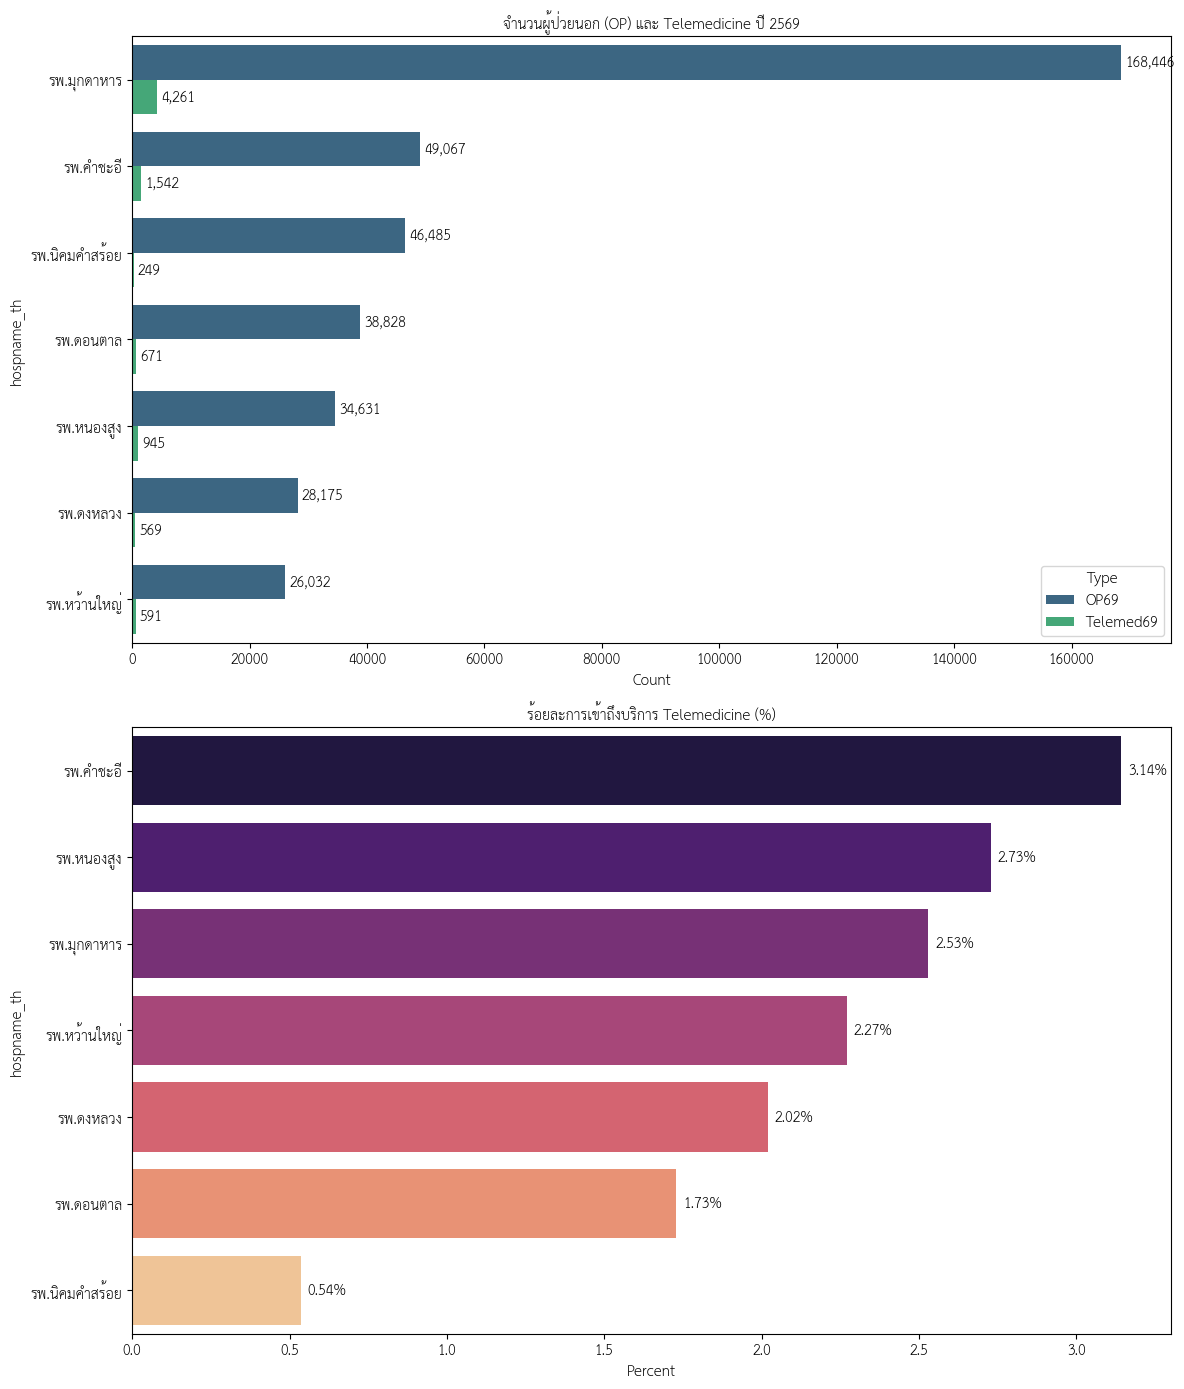


📊 สรุปรายงาน 7 โรงพยาบาลหลัก:
hospcode    hospname_th   OP69  Telemed69  Percent
   10712    รพ.มุกดาหาร 168446     4261.0 2.529594
   11116      รพ.คำชะอี  49067     1542.0 3.142642
   11113 รพ.นิคมคำสร้อย  46485      249.0 0.535657
   11114      รพ.ดอนตาล  38828      671.0 1.728134
   11118     รพ.หนองสูง  34631      945.0 2.728769
   11115      รพ.ดงหลวง  28175      569.0 2.019521
   11117   รพ.หว้านใหญ่  26032      591.0 2.270283


In [31]:
import pandas as pd
import zipfile
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None
    print("⚠️ ไม่พบฟอนต์ภาษาไทย")

# --- 2. ฟังก์ชันดึงข้อมูลจาก Excel ที่พัง (Inline Strings) ---
def extract_excel_data(file_path):
    data = []
    ns = {'ns': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}
    with zipfile.ZipFile(file_path, 'r') as z:
        with z.open('xl/worksheets/sheet1.xml') as f:
            tree = ET.parse(f)
            root = tree.getroot()
            for row in root.findall('.//ns:row', ns):
                row_data = []
                for cell in row.findall('ns:c', ns):
                    v = cell.find('ns:v', ns)
                    is_tag = cell.find('ns:is/ns:t', ns)
                    if is_tag is not None: row_data.append(is_tag.text)
                    elif v is not None: row_data.append(v.text)
                    else: row_data.append(None)
                data.append(row_data)
    return pd.DataFrame(data[1:], columns=data[0])

# --- 3. จัดการไฟล์และเตรียมข้อมูล ---
source_xlsx = 'Export/20260427_49_telemed_hosp.xlsx'
target_csv = 'telemed_hosp_final.csv'

try:
    # ถ้ายังไม่มีไฟล์ CSV ให้สร้างใหม่จากการผ่าตัด XML
    if not os.path.exists(target_csv):
        print(f"⏳ กำลังสร้างไฟล์ {target_csv} จาก {source_xlsx}...")
        df_raw = extract_excel_data(source_xlsx)
        df_raw.to_csv(target_csv, index=False, encoding='utf-8-sig')
    
    # โหลดข้อมูลมาทำรายงาน
    df = pd.read_csv(target_csv)
    
    # รายชื่อ 7 รพ.
    hosp_targets = {
        '10712': 'รพ.มุกดาหาร', '11113': 'รพ.นิคมคำสร้อย', 
        '11114': 'รพ.ดอนตาล', '11115': 'รพ.ดงหลวง', 
        '11116': 'รพ.คำชะอี', '11117': 'รพ.หว้านใหญ่', 
        '11118': 'รพ.หนองสูง'
    }

    # Clean ข้อมูล
    df['hospcode'] = df['hospcode'].astype(str).str.split('.').str[0].str.strip()
    for col in ['OP69', 'Telemed69']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df_hosp = df[df['hospcode'].isin(hosp_targets.keys())].copy()
    df_hosp['hospname_th'] = df_hosp['hospcode'].map(hosp_targets)
    df_hosp['Percent'] = (df_hosp['Telemed69'] / df_hosp['OP69'] * 100).fillna(0)
    df_hosp = df_hosp.sort_values(by='OP69', ascending=False)

    # --- 4. วาดกราฟรายงาน ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))

    # กราฟ 1: จำนวนบริการ
    df_melted = df_hosp.melt(id_vars='hospname_th', value_vars=['OP69', 'Telemed69'], var_name='Type', value_name='Count')
    sns.barplot(data=df_melted, x='Count', y='hospname_th', hue='Type', palette='viridis', ax=ax1)
    ax1.set_title('จำนวนผู้ป่วยนอก (OP) และ Telemedicine ปี 2569', fontsize=16, fontweight='bold', fontproperties=prop)
    for c in ax1.containers: ax1.bar_label(c, padding=3, fmt='{:,.0f}')

    # กราฟ 2: ร้อยละการเข้าถึง
    df_pct = df_hosp.sort_values(by='Percent', ascending=False)
    sns.barplot(data=df_pct, x='Percent', y='hospname_th', palette='magma', ax=ax2, hue='hospname_th', legend=False)
    ax2.set_title('ร้อยละการเข้าถึงบริการ Telemedicine (%)', fontsize=16, fontweight='bold', fontproperties=prop)
    for c in ax2.containers: ax2.bar_label(c, padding=5, fmt='%.2f%%')

    plt.tight_layout()
    plt.show()

    # --- 5. สรุปตาราง ---
    print("\n📊 สรุปรายงาน 7 โรงพยาบาลหลัก:")
    print(df_hosp[['hospcode', 'hospname_th', 'OP69', 'Telemed69', 'Percent']].to_string(index=False))

except Exception as e:
    print(f"❌ เกิดข้อผิดพลาด: {e}")
    print("💡 คำแนะนำ: ตรวจสอบว่าไฟล์ .xlsx อยู่ในโฟลเดอร์ Export/ หรือไม่")

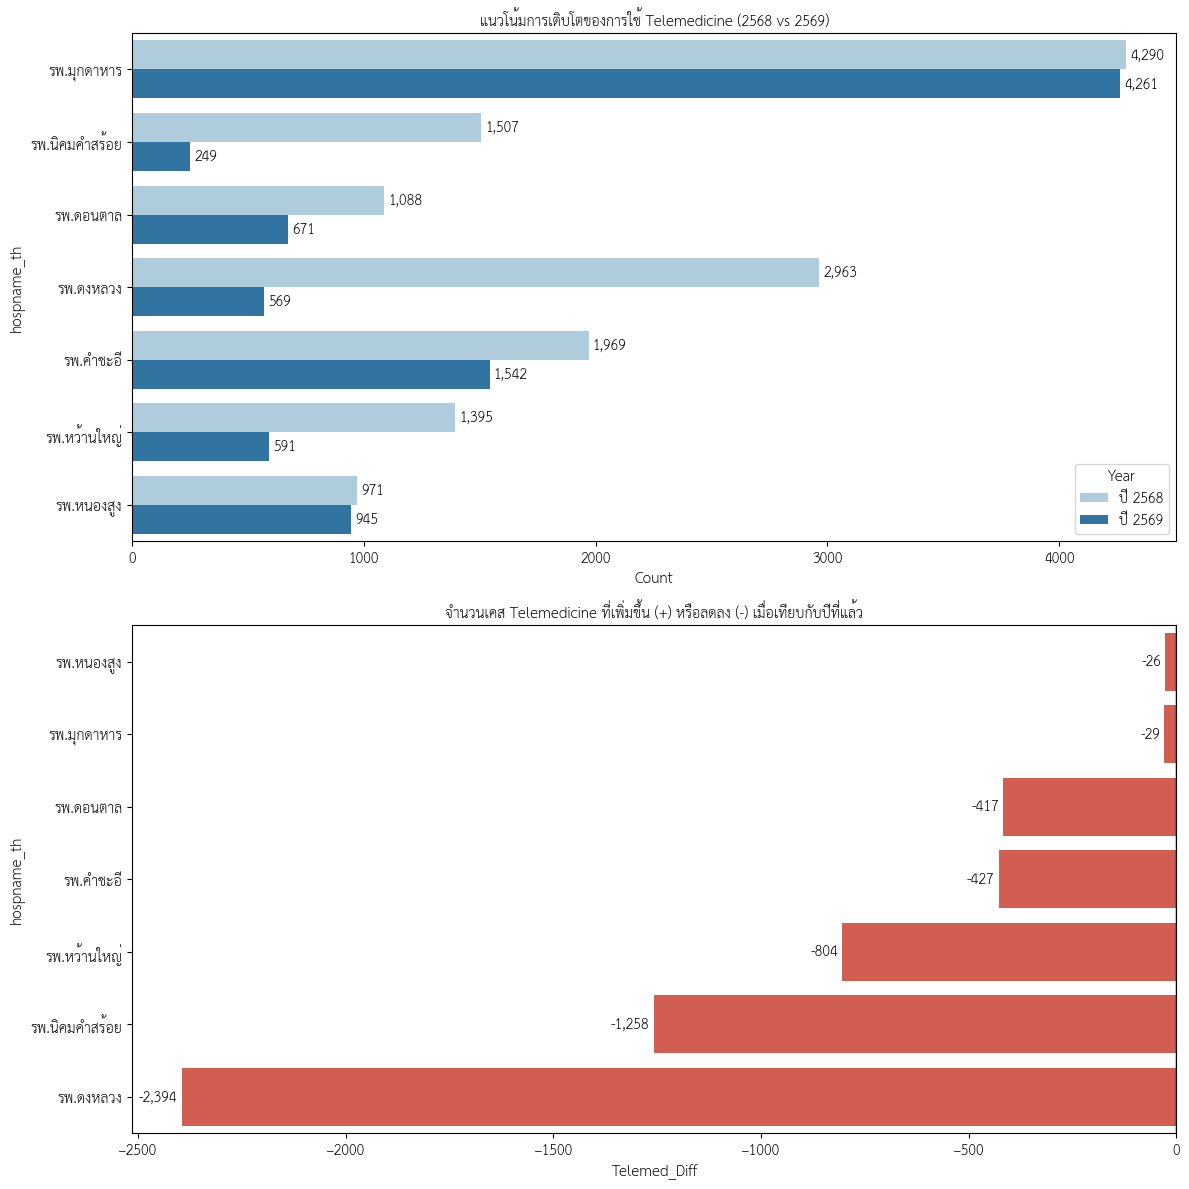


📝 บทวิเคราะห์ผลการดำเนินงาน:
- รพ.หนองสูง: ปี 69 ทำได้ 945 เคส (ลดลง 📉 26 เคส)
- รพ.มุกดาหาร: ปี 69 ทำได้ 4261 เคส (ลดลง 📉 29 เคส)
- รพ.ดอนตาล: ปี 69 ทำได้ 671 เคส (ลดลง 📉 417 เคส)
- รพ.คำชะอี: ปี 69 ทำได้ 1542 เคส (ลดลง 📉 427 เคส)
- รพ.หว้านใหญ่: ปี 69 ทำได้ 591 เคส (ลดลง 📉 804 เคส)
- รพ.นิคมคำสร้อย: ปี 69 ทำได้ 249 เคส (ลดลง 📉 1258 เคส)
- รพ.ดงหลวง: ปี 69 ทำได้ 569 เคส (ลดลง 📉 2394 เคส)


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
    prop = fm.FontProperties(fname=font_path)

# --- 2. โหลดข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')

# รายชื่อ 7 รพ. หลัก
hosp_targets = {
    '10712': 'รพ.มุกดาหาร', '11113': 'รพ.นิคมคำสร้อย', 
    '11114': 'รพ.ดอนตาล', '11115': 'รพ.ดงหลวง', 
    '11116': 'รพ.คำชะอี', '11117': 'รพ.หว้านใหญ่', 
    '11118': 'รพ.หนองสูง'
}

# Clean ข้อมูล
df['hospcode'] = df['hospcode'].astype(str).str.split('.').str[0].str.strip()
cols = ['OP68', 'Telemed68', 'OP69', 'Telemed69']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_hosp = df[df['hospcode'].isin(hosp_targets.keys())].copy()
df_hosp['hospname_th'] = df_hosp['hospcode'].map(hosp_targets)

# คำนวณส่วนต่างการเติบโต (ปี 69 เทียบกับ 68)
df_hosp['Telemed_Diff'] = df_hosp['Telemed69'] - df_hosp['Telemed68']

# --- 3. สร้าง Dashboard 2 ส่วน ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# กราฟที่ 1: เปรียบเทียบปี 68 vs 69 (ดูแนวโน้ม)
df_growth = df_hosp.melt(id_vars='hospname_th', value_vars=['Telemed68', 'Telemed69'], 
                         var_name='Year', value_name='Count')
df_growth['Year'] = df_growth['Year'].map({'Telemed68': 'ปี 2568', 'Telemed69': 'ปี 2569'})

sns.barplot(data=df_growth, x='Count', y='hospname_th', hue='Year', palette='Paired', ax=ax1)
ax1.set_title('แนวโน้มการเติบโตของการใช้ Telemedicine (2568 vs 2569)', fontsize=16, fontweight='bold', fontproperties=prop)
for c in ax1.containers: ax1.bar_label(c, padding=3, fmt='{:,.0f}')

# กราฟที่ 2: จำนวนเคสที่เพิ่มขึ้น/ลดลง (Net Change)
df_hosp = df_hosp.sort_values(by='Telemed_Diff', ascending=False)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in df_hosp['Telemed_Diff']]
sns.barplot(data=df_hosp, x='Telemed_Diff', y='hospname_th', palette=colors, ax=ax2, hue='hospname_th', legend=False)
ax2.set_title('จำนวนเคส Telemedicine ที่เพิ่มขึ้น (+) หรือลดลง (-) เมื่อเทียบกับปีที่แล้ว', fontsize=16, fontweight='bold', fontproperties=prop)
ax2.axvline(0, color='black', lw=1) # เส้นแบ่ง 0
for c in ax2.containers: ax2.bar_label(c, padding=3, fmt='{:,.0f}')

plt.tight_layout()
plt.show()

# --- 4. สรุปวิเคราะห์รายโรงพยาบาล ---
print("\n📝 บทวิเคราะห์ผลการดำเนินงาน:")
for _, row in df_hosp.iterrows():
    status = "เพิ่มขึ้น 📈" if row['Telemed_Diff'] > 0 else "ลดลง 📉" if row['Telemed_Diff'] < 0 else "คงที่ ➖"
    print(f"- {row['hospname_th']}: ปี 69 ทำได้ {row['Telemed69']:.0f} เคส ({status} {abs(row['Telemed_Diff']):.0f} เคส)")

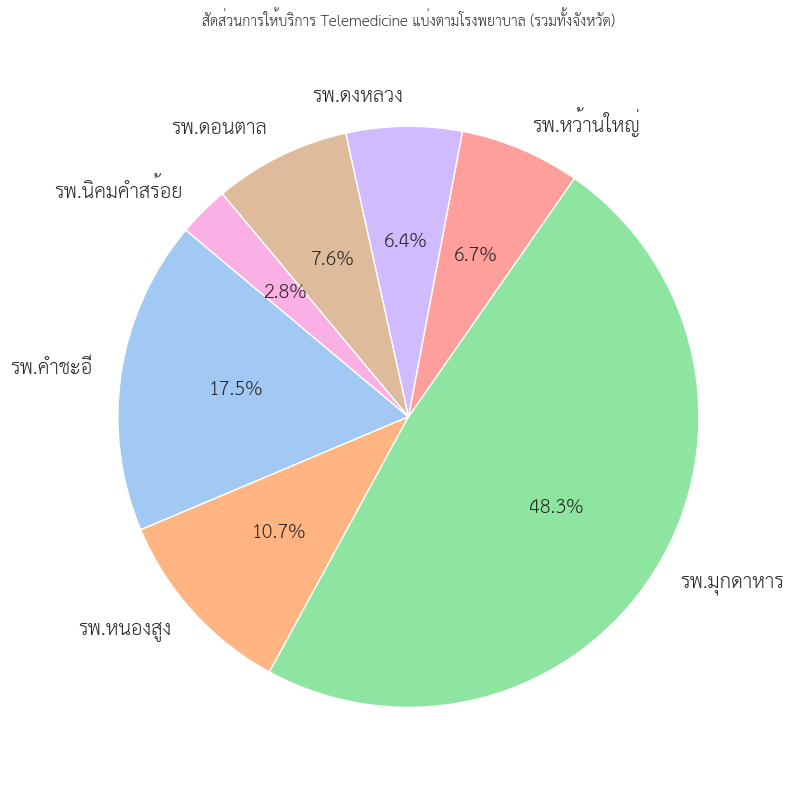


🏆 บทสรุปผู้บริหาร (Executive Summary):
------------------------------------------------------------
⭐ หน่วยงานที่มีประสิทธิภาพสูงสุด: รพ.คำชะอี (เข้าถึงบริการ 3.14%)
📈 ภาพรวมทั้งจังหวัด: ผู้ป่วยนอกทั้งหมด 391,664 ราย | ใช้ Telemed 8,828 ราย
📊 ค่าเฉลี่ยการเข้าถึงบริการทั้งจังหวัด: 2.25%
------------------------------------------------------------


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)

# --- 2. โหลดข้อมูลจาก CSV ที่เราเตรียมไว้ ---
df = pd.read_csv('telemed_hosp_final.csv')

# รายชื่อ 7 รพ. หลัก
hosp_targets = {
    '10712': 'รพ.มุกดาหาร', '11113': 'รพ.นิคมคำสร้อย', 
    '11114': 'รพ.ดอนตาล', '11115': 'รพ.ดงหลวง', 
    '11116': 'รพ.คำชะอี', '11117': 'รพ.หว้านใหญ่', 
    '11118': 'รพ.หนองสูง'
}

# Clean ข้อมูลและคำนวณ KPI
df['hospcode'] = df['hospcode'].astype(str).str.split('.').str[0].str.strip()
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_hosp = df[df['hospcode'].isin(hosp_targets.keys())].copy()
df_hosp['hospname_th'] = df_hosp['hospcode'].map(hosp_targets)

# KPI 1: Telemed Utilization (ร้อยละต่อ OP)
df_hosp['Utilization'] = (df_hosp['Telemed69'] / df_hosp['OP69'] * 100).fillna(0)

# KPI 2: Efficiency Rank (เรียงลำดับตามประสิทธิภาพ)
df_hosp = df_hosp.sort_values(by='Utilization', ascending=False)

# --- 3. สร้างกราฟสรุปภาพรวม (Final Dashboard) ---
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# กราฟวงกลม (Pie Chart) แสดงสัดส่วนการใช้ Telemed รวมของทั้งจังหวัดแยกตามรพ.
total_telemed = df_hosp['Telemed69'].sum()
plt.subplot(1, 1, 1)
colors = sns.color_palette('pastel')[0:7]
plt.pie(df_hosp['Telemed69'], labels=df_hosp['hospname_th'], autopct='%1.1f%%', 
        startangle=140, colors=colors, textprops={'fontproperties': prop, 'fontsize': 14})
plt.title('สัดส่วนการให้บริการ Telemedicine แบ่งตามโรงพยาบาล (รวมทั้งจังหวัด)', 
          fontsize=18, fontweight='bold', fontproperties=prop, pad=20)

plt.tight_layout()
plt.savefig('final_pie_chart.png')
plt.show()

# --- 4. สรุปภาพรวมเป็นตาราง Executive Summary ---
print("\n🏆 บทสรุปผู้บริหาร (Executive Summary):")
print("-" * 60)
top_performer = df_hosp.iloc[0]
print(f"⭐ หน่วยงานที่มีประสิทธิภาพสูงสุด: {top_performer['hospname_th']} (เข้าถึงบริการ {top_performer['Utilization']:.2f}%)")

total_op = df_hosp['OP69'].sum()
total_tm = df_hosp['Telemed69'].sum()
avg_pct = (total_tm / total_op) * 100

print(f"📈 ภาพรวมทั้งจังหวัด: ผู้ป่วยนอกทั้งหมด {total_op:,.0f} ราย | ใช้ Telemed {total_tm:,.0f} ราย")
print(f"📊 ค่าเฉลี่ยการเข้าถึงบริการทั้งจังหวัด: {avg_pct:.2f}%")
print("-" * 60)

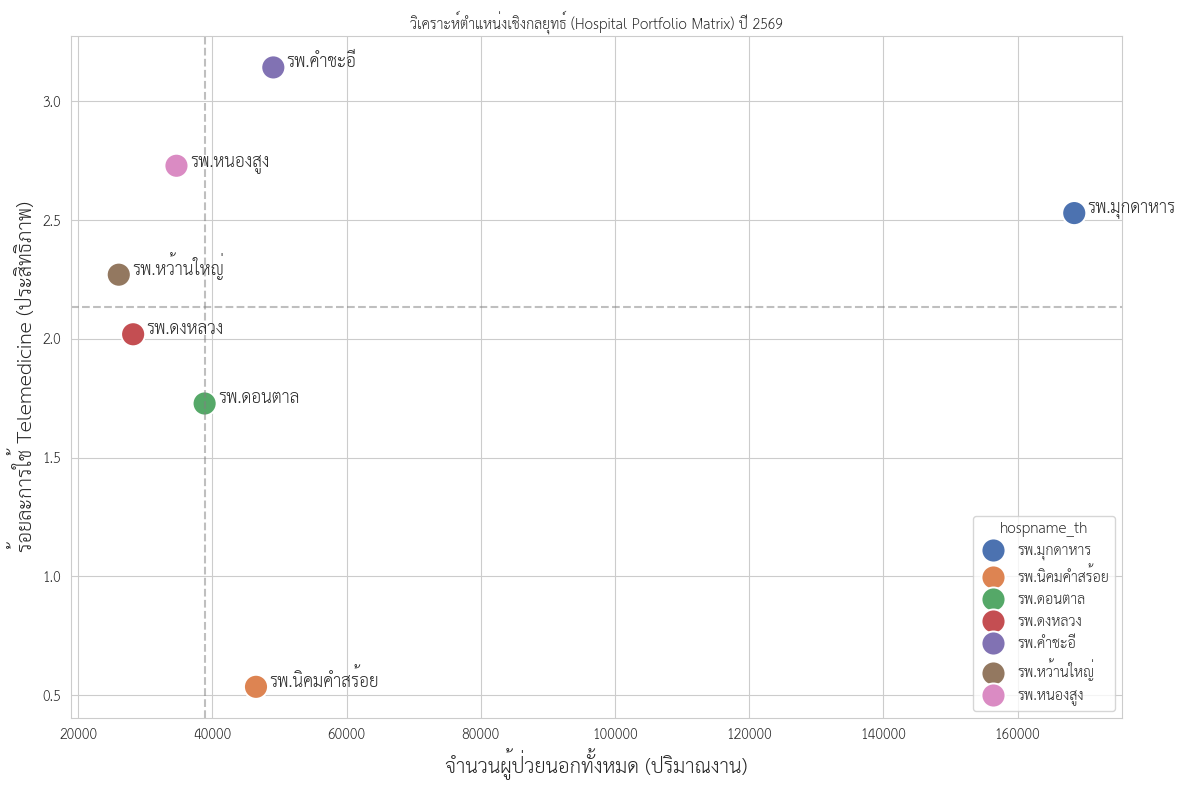


🎯 ตารางวิเคราะห์เป้าหมายร้อยละ 5 (Gap Analysis):
   hospname_th  Telemed69  Target_Cases    Gap
   รพ.มุกดาหาร     4261.0        8422.0 4161.0
รพ.นิคมคำสร้อย      249.0        2324.0 2075.0
     รพ.ดอนตาล      671.0        1941.0 1270.0
     รพ.คำชะอี     1542.0        2453.0  911.0
     รพ.ดงหลวง      569.0        1409.0  840.0
    รพ.หนองสูง      945.0        1732.0  787.0
  รพ.หว้านใหญ่      591.0        1302.0  711.0


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
    prop = fm.FontProperties(fname=font_path)

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
hosp_targets = {'10712':'รพ.มุกดาหาร', '11113':'รพ.นิคมคำสร้อย', '11114':'รพ.ดอนตาล', 
                '11115':'รพ.ดงหลวง', '11116':'รพ.คำชะอี', '11117':'รพ.หว้านใหญ่', '11118':'รพ.หนองสูง'}

df['hospcode'] = df['hospcode'].astype(str).str.split('.').str[0].str.strip()
for col in ['OP69', 'Telemed69']: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_hosp = df[df['hospcode'].isin(hosp_targets.keys())].copy()
df_hosp['hospname_th'] = df_hosp['hospcode'].map(hosp_targets)
df_hosp['Utilization'] = (df_hosp['Telemed69'] / df_hosp['OP69'] * 100).fillna(0)

# คำนวณช่องว่างสู่เป้าหมายร้อยละ 5 (Target Gap)
target_pct = 5.0
df_hosp['Target_Cases'] = (df_hosp['OP69'] * (target_pct / 100)).round(0)
df_hosp['Gap'] = (df_hosp['Target_Cases'] - df_hosp['Telemed69']).clip(lower=0)

# --- 3. สร้าง Portfolio Matrix (Scatter Plot) ---
plt.figure(figsize=(12, 8))
avg_op = df_hosp['OP69'].median()
avg_util = df_hosp['Utilization'].mean()

sns.scatterplot(data=df_hosp, x='OP69', y='Utilization', s=300, hue='hospname_th', palette='deep')

# ขีดเส้นแบ่ง Quadrant
plt.axvline(avg_op, color='grey', linestyle='--', alpha=0.5)
plt.axhline(avg_util, color='grey', linestyle='--', alpha=0.5)

# ใส่ชื่อโรงพยาบาลกำกับจุด
for i in range(df_hosp.shape[0]):
    plt.text(df_hosp.OP69.iloc[i]+2000, df_hosp.Utilization.iloc[i], 
             df_hosp.hospname_th.iloc[i], fontproperties=prop, fontsize=12)

plt.title('วิเคราะห์ตำแหน่งเชิงกลยุทธ์ (Hospital Portfolio Matrix) ปี 2569', fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนผู้ป่วยนอกทั้งหมด (ปริมาณงาน)', fontsize=14, fontproperties=prop)
plt.ylabel('ร้อยละการใช้ Telemedicine (ประสิทธิภาพ)', fontsize=14, fontproperties=prop)

plt.tight_layout()
plt.savefig('strategic_matrix.png')
plt.show()

# --- 4. ตารางวิเคราะห์ Gap Analysis ---
print("\n🎯 ตารางวิเคราะห์เป้าหมายร้อยละ 5 (Gap Analysis):")
summary_gap = df_hosp[['hospname_th', 'Telemed69', 'Target_Cases', 'Gap']].sort_values(by='Gap', ascending=False)
print(summary_gap.to_string(index=False))

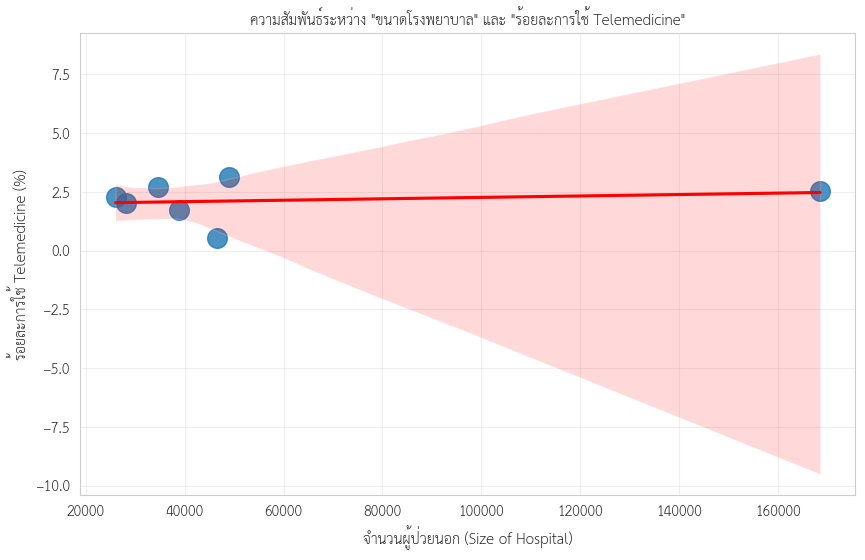


🚀 ตารางพยากรณ์และแผนปฏิบัติการปี 2570:
   hospname_th  Telemed69  Forecast_2570                   Recommended_Action
   รพ.มุกดาหาร     4261.0    4232.196037    Model: ขยายผลสู่ รพ.สต. เครือข่าย
     รพ.คำชะอี     1542.0    1207.599797    Model: ขยายผลสู่ รพ.สต. เครือข่าย
    รพ.หนองสูง      945.0     919.696189    Model: ขยายผลสู่ รพ.สต. เครือข่าย
     รพ.ดอนตาล      671.0     413.824449   Boost: เพิ่มสิทธิประโยชน์/แรงจูงใจ
  รพ.หว้านใหญ่      591.0     250.380645    Model: ขยายผลสู่ รพ.สต. เครือข่าย
     รพ.ดงหลวง      569.0     109.267972    Model: ขยายผลสู่ รพ.สต. เครือข่าย
รพ.นิคมคำสร้อย      249.0      41.142004 Refactor: ปรับปรุง Workflow/ระบบไอที


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import numpy as np
import os

# --- 1. ตั้งค่าฟอนต์ ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
    prop = fm.FontProperties(fname=font_path)

# --- 2. โหลดข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
hosp_targets = {'10712':'รพ.มุกดาหาร', '11113':'รพ.นิคมคำสร้อย', '11114':'รพ.ดอนตาล', 
                '11115':'รพ.ดงหลวง', '11116':'รพ.คำชะอี', '11117':'รพ.หว้านใหญ่', '11118':'รพ.หนองสูง'}

df['hospcode'] = df['hospcode'].astype(str).str.split('.').str[0].str.strip()
cols = ['OP68', 'Telemed68', 'OP69', 'Telemed69']
for col in cols: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_hosp = df[df['hospcode'].isin(hosp_targets.keys())].copy()
df_hosp['hospname_th'] = df_hosp['hospcode'].map(hosp_targets)
df_hosp['Utilization'] = (df_hosp['Telemed69'] / df_hosp['OP69'] * 100).fillna(0)

# --- 3. การวิเคราะห์ความสัมพันธ์ (Correlation) ---
plt.figure(figsize=(10, 6))
sns.regplot(data=df_hosp, x='OP69', y='Utilization', scatter_kws={'s':200}, line_kws={'color':'red'})
plt.title('ความสัมพันธ์ระหว่าง "ขนาดโรงพยาบาล" และ "ร้อยละการใช้ Telemedicine"', 
          fontsize=16, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนผู้ป่วยนอก (Size of Hospital)', fontproperties=prop)
plt.ylabel('ร้อยละการใช้ Telemedicine (%)', fontproperties=prop)
plt.grid(True, alpha=0.3)
plt.show()

# --- 4. พยากรณ์ปี 2570 (Simple Forecasting) ---
# คำนวณ Growth Rate (ปี 69 เทียบ 68)
df_hosp['Growth_Rate'] = ((df_hosp['Telemed69'] - df_hosp['Telemed68']) / df_hosp['Telemed68'].replace(0, np.nan)).fillna(0)
# พยากรณ์ปี 70 โดยใช้ Growth Rate เดิม (แต่ไม่เกิน 100% growth เพื่อความสมจริง)
df_hosp['Forecast_2570'] = df_hosp['Telemed69'] * (1 + df_hosp['Growth_Rate'].clip(upper=1.0))

# --- 5. สรุปตาราง Action Plan รายกลุ่ม ---
def suggest_action(row):
    if row['Utilization'] >= 2.0: return "Model: ขยายผลสู่ รพ.สต. เครือข่าย"
    if row['Utilization'] >= 1.0: return "Boost: เพิ่มสิทธิประโยชน์/แรงจูงใจ"
    return "Refactor: ปรับปรุง Workflow/ระบบไอที"

df_hosp['Recommended_Action'] = df_hosp.apply(suggest_action, axis=1)

print("\n🚀 ตารางพยากรณ์และแผนปฏิบัติการปี 2570:")
summary_final = df_hosp[['hospname_th', 'Telemed69', 'Forecast_2570', 'Recommended_Action']].sort_values(by='Forecast_2570', ascending=False)
print(summary_final.to_string(index=False))

ฝั่ง รพสต.   (อปท)

✅ ติดตั้งฟอนต์สำเร็จ: TH Sarabun New


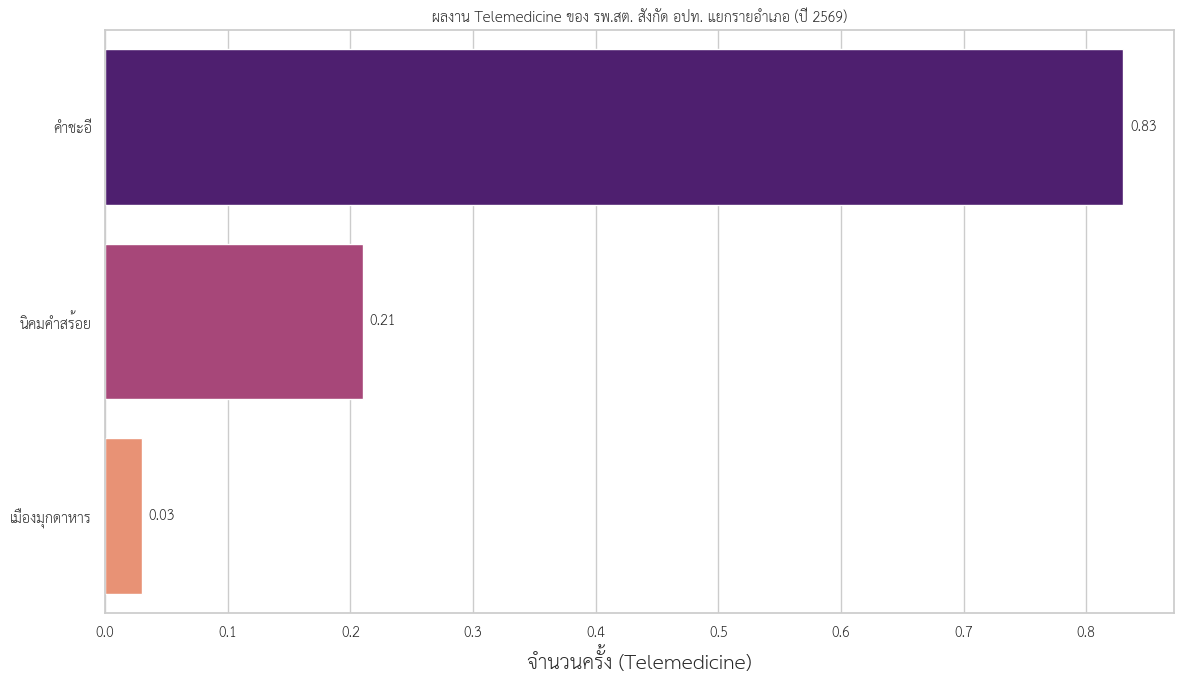


📊 สรุปรายงานรายอำเภอ (เฉพาะกลุ่ม อปท.):
        อำเภอ  จำนวน รพ.สต. อปท.  ผู้ป่วยนอกรวม (OP69)  Telemedicine รวม  % การเข้าถึง
       คำชะอี                 12                    36              0.83      2.305556
  นิคมคำสร้อย                 10                    10              0.21      2.100000
เมืองมุกดาหาร                 22                     3              0.03      1.000000
       ดอนตาล                 13                     0              0.00      0.000000
       ดงหลวง                  9                     0              0.00      0.000000
      หนองสูง                  6                     0              0.00      0.000000
    หว้านใหญ่                  6                     0              0.00      0.000000

🏆 รายชื่อ รพ.สต. อปท. ที่มียอดใช้งานสูงสุด (Top 10):
                                               hospname      AMP_NAME  OP69  Telemed69  % การเข้าถึง
               สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ        คำชะอี    33       0.75      2.272727
       

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย (รองรับทัง Title และ Ticks) ---
# ระบุพาธฟอนต์ที่คุณใช้งาน
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    prop = fm.FontProperties(fname=font_path)
    print(f"✅ ติดตั้งฟอนต์สำเร็จ: {font_name}")
else:
    font_name = 'sans-serif'
    prop = None
    print("⚠️ ไม่พบฟอนต์ภาษาไทย กราฟอาจแสดงผลเป็นสี่เหลี่ยม")

# --- 2. โหลดและเตรียมข้อมูล ---
file_path = 'telemed_hosp_final.csv'
if not os.path.exists(file_path):
    print(f"❌ ไม่พบไฟล์ {file_path}")
else:
    df = pd.read_csv(file_path)

    # แปลงคอลัมน์ตัวเลขให้พร้อมคำนวณ
    cols_to_fix = ['OP69', 'Telemed69', 'OP68', 'Telemed68']
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # --- 3. กรองข้อมูลเฉพาะกลุ่ม อปท. (M_NAME == 'องค์กรปกครองส่วนท้องถิ่น') ---
    lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

    # --- 4. สรุปรายงานรายอำเภอ (ไม่มี รหัส รพ.) ---
    lgo_amp_summary = lgo_df.groupby('AMP_NAME').agg({
        'hospname': 'count', # นับจำนวนแห่ง
        'OP69': 'sum',
        'Telemed69': 'sum'
    }).reset_index()
    
    lgo_amp_summary.columns = ['อำเภอ', 'จำนวน รพ.สต. อปท.', 'ผู้ป่วยนอกรวม (OP69)', 'Telemedicine รวม']
    
    # คำนวณร้อยละการเข้าถึง
    lgo_amp_summary['% การเข้าถึง'] = (lgo_amp_summary['Telemedicine รวม'] / lgo_amp_summary['ผู้ป่วยนอกรวม (OP69)'] * 100).fillna(0)
    lgo_amp_summary = lgo_amp_summary.sort_values(by='Telemedicine รวม', ascending=False)

    # --- 5. สรุปรายชื่อ รพ.สต. ที่มีผลงานสูงสุด (ไม่มี รหัส รพ.) ---
    lgo_active_centers = lgo_df[lgo_df['Telemed69'] > 0].copy()
    lgo_active_centers = lgo_active_centers[['hospname', 'AMP_NAME', 'OP69', 'Telemed69']].sort_values(by='Telemed69', ascending=False)
    lgo_active_centers['% การเข้าถึง'] = (lgo_active_centers['Telemed69'] / lgo_active_centers['OP69'] * 100).fillna(0)

    # --- 6. วาดกราฟเปรียบเทียบผลงานรายอำเภอ ---
    plt.figure(figsize=(12, 7))
    sns.set_theme(style="whitegrid", font=font_name) 

    plot_data = lgo_amp_summary[lgo_amp_summary['Telemedicine รวม'] > 0]

    if not plot_data.empty:
        ax = sns.barplot(data=plot_data, x='Telemedicine รวม', y='อำเภอ', palette='magma', hue='อำเภอ', legend=False)
        
        plt.title('ผลงาน Telemedicine ของ รพ.สต. สังกัด อปท. แยกรายอำเภอ (ปี 2569)', 
                  fontsize=18, fontweight='bold', fontproperties=prop)
        plt.xlabel('จำนวนครั้ง (Telemedicine)', fontsize=14, fontproperties=prop)
        plt.ylabel('', fontproperties=prop)
        
        # บังคับฟอนต์ที่แกน
        plt.xticks(fontproperties=prop)
        plt.yticks(fontproperties=prop)
        
        # ใส่ตัวเลขท้ายแท่ง
        for container in ax.containers:
            ax.bar_label(container, padding=5, fmt='%.2f', fontweight='bold', fontproperties=prop)
    else:
        plt.text(0.5, 0.5, 'ไม่พบข้อมูลการใช้ Telemedicine ในกลุ่ม อปท.', ha='center', va='center', fontsize=16, fontproperties=prop)

    plt.tight_layout()
    plt.savefig('report_lgo_district_v2.png', dpi=300)
    plt.show()

    # --- 7. แสดงผลและบันทึกรายงาน ---
    print("\n📊 สรุปรายงานรายอำเภอ (เฉพาะกลุ่ม อปท.):")
    print(lgo_amp_summary.to_string(index=False))
    
    print("\n🏆 รายชื่อ รพ.สต. อปท. ที่มียอดใช้งานสูงสุด (Top 10):")
    print(lgo_active_centers.head(10).to_string(index=False))

    # เซฟไฟล์รายงานแยก 2 ส่วน (ภาษาไทยไม่พังใน Excel)
    lgo_amp_summary.to_csv('lgo_district_summary.csv', index=False, encoding='utf-8-sig')
    lgo_active_centers.to_csv('lgo_active_centers_report.csv', index=False, encoding='utf-8-sig')
    print("\n✅ เซฟรายงานสำเร็จ: 'lgo_district_summary.csv' และ 'lgo_active_centers_report.csv'")

✅ ใช้ฟอนต์: TH Sarabun New


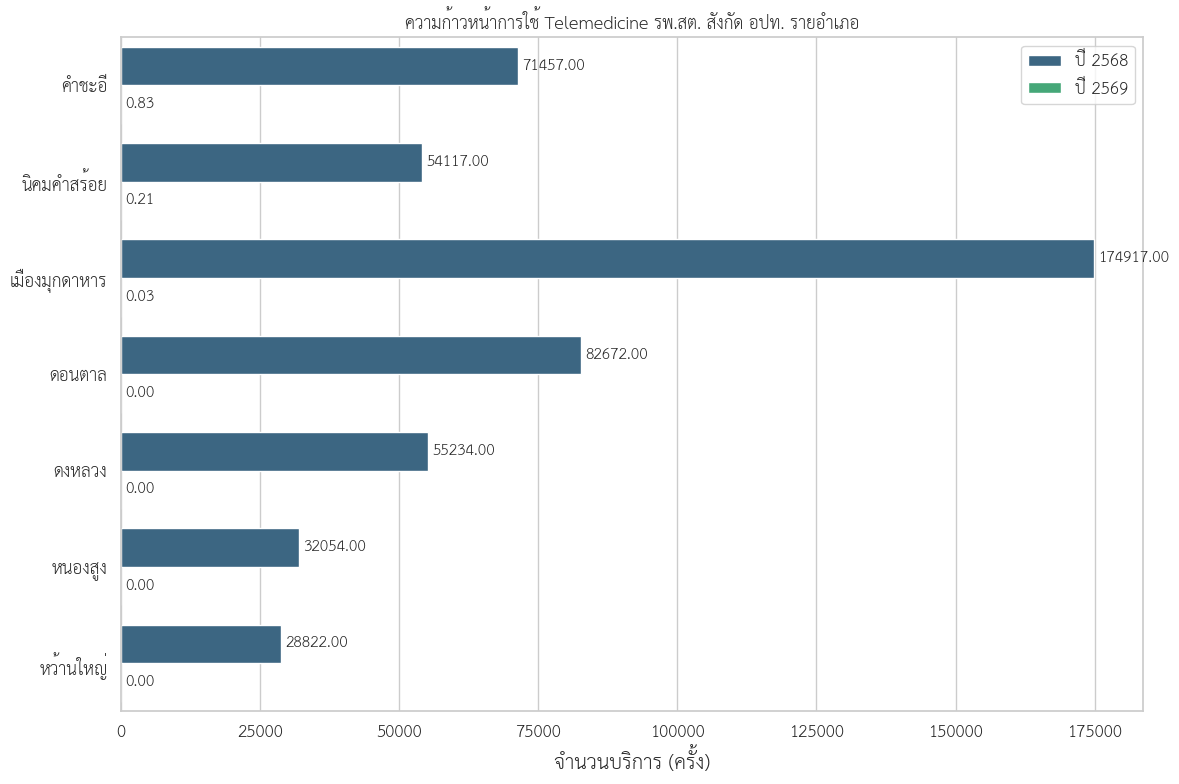


🏅 รพ.สต. สังกัด อปท. ที่มีผลงานโดดเด่นสูงสุด (Top 10):
 hospcode                                                hospname      AMP_NAME  Telemed69
    13985                สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ        คำชะอี       0.75
     5799            โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านคำบก ตำบลคำบก        คำชะอี       0.08
     5760 โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านภูแผงม้า ตำบลนิคมคำสร้อย   นิคมคำสร้อย       0.06
     5766   โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านทรายไหลแล้ง ตำบลนาอุดม   นิคมคำสร้อย       0.04
     5764      โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านเหล่ากลาง ตำบลกกแดง   นิคมคำสร้อย       0.03
     5765        โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านนาอุดม ตำบลนาอุดม   นิคมคำสร้อย       0.02
     5756        โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านดงเย็น ตำบลดงเย็น เมืองมุกดาหาร       0.02
    11759     โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านโนนสวรรค์  ตำบลนากอก   นิคมคำสร้อย       0.02
     5762                 โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านหนองแวง    นิคมคำสร้อย       0.02
     5767      โรงพยาบาลส่งเสริมสุ

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทยให้ครอบคลุม (แก้ปัญหาตัวสี่เหลี่ยม) ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    prop = fm.FontProperties(fname=font_path)
    print(f"✅ ใช้ฟอนต์: {font_name}")
else:
    prop = None
    print("⚠️ ไม่พบฟอนต์ภาษาไทย")

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')

# แปลงข้อมูลตัวเลข
num_cols = ['OP68', 'Telemed68', 'OP69', 'Telemed69']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะกลุ่ม อปท.
lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# --- 3. วิเคราะห์เชิงลึกรายอำเภอ (อปท.) ---
lgo_summary = lgo_df.groupby('AMP_NAME').agg({
    'hospcode': 'count',
    'Telemed68': 'sum',
    'Telemed69': 'sum'
}).reset_index()

# คำนวณส่วนต่างการพัฒนา (Growth)
lgo_summary['Development'] = lgo_summary['Telemed69'] - lgo_summary['Telemed68']
lgo_summary = lgo_summary.sort_values(by='Telemed69', ascending=False)

# --- 4. สร้าง Dashboard รายงาน ---
fig, ax = plt.subplots(figsize=(12, 8))

# สร้างกราฟเปรียบเทียบ 2 ปี
df_melted = lgo_summary.melt(id_vars='AMP_NAME', value_vars=['Telemed68', 'Telemed69'], 
                             var_name='Year', value_name='Count')
df_melted['Year'] = df_melted['Year'].map({'Telemed68': 'ปี 2568', 'Telemed69': 'ปี 2569'})

sns.barplot(data=df_melted, x='Count', y='AMP_NAME', hue='Year', palette='viridis', ax=ax)

# ตั้งค่าหัวข้อและแกน (ภาษาไทย)
plt.title('ความก้าวหน้าการใช้ Telemedicine รพ.สต. สังกัด อปท. รายอำเภอ', 
          fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนบริการ (ครั้ง)', fontsize=14, fontproperties=prop)
plt.ylabel('', fontproperties=prop)
plt.xticks(fontproperties=prop)
plt.yticks(fontproperties=prop)
plt.legend(prop=prop)

# ใส่ตัวเลขท้ายแท่งกราฟ
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%.2f', fontproperties=prop, fontsize=11)

plt.tight_layout()
plt.savefig('lgo_comprehensive_report.png', dpi=300)
plt.show()

# --- 5. สรุปผลสรุปรายแห่ง (Top 10 Performers) ---
print("\n🏅 รพ.สต. สังกัด อปท. ที่มีผลงานโดดเด่นสูงสุด (Top 10):")
top_10 = lgo_df[lgo_df['Telemed69'] > 0].sort_values(by='Telemed69', ascending=False).head(10)
print(top_10[['hospcode', 'hospname', 'AMP_NAME', 'Telemed69']].to_string(index=False))

# เซฟไฟล์รายงานสรุป (ภาษาไทยออกครบ 100%)
lgo_summary.to_csv('lgo_final_report_thai.csv', index=False, encoding='utf-8-sig')
print("\n✅ บันทึกไฟล์รายงานภาษาไทยที่: lgo_final_report_thai.csv")

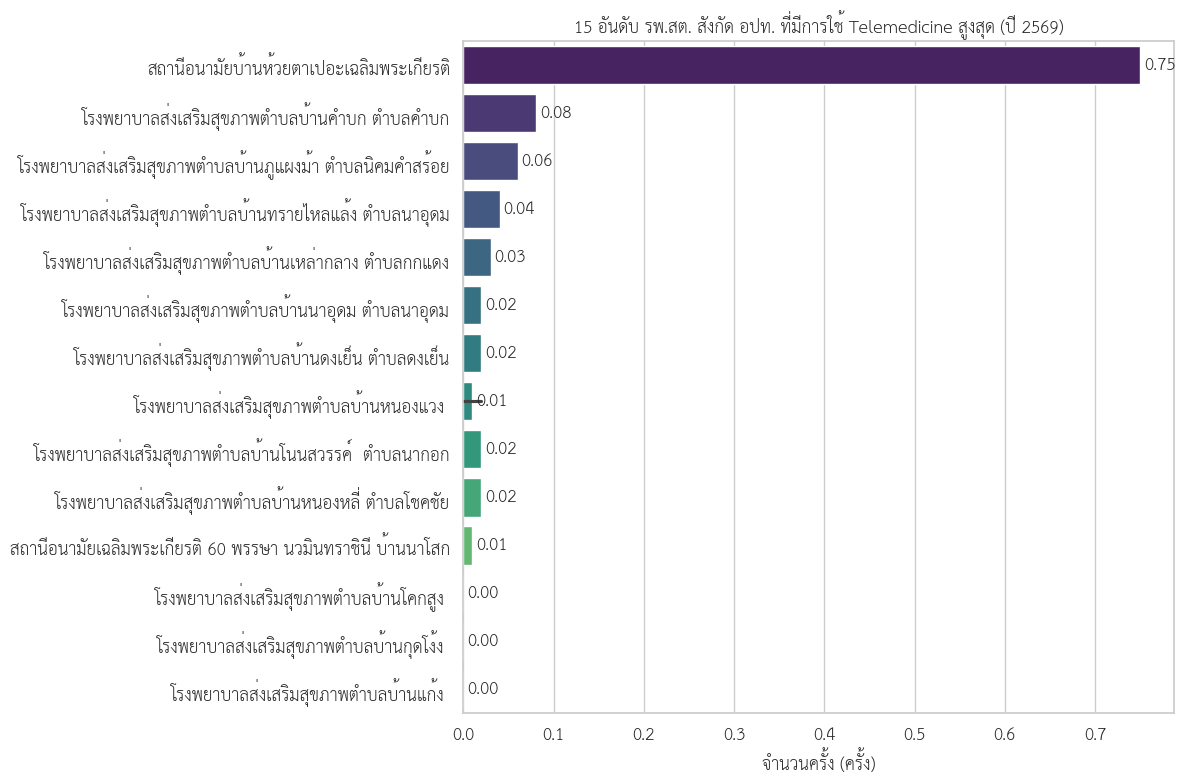

📊 ตรวจพบ รพ.สต. สังกัด อปท. ทั้งหมด: 78 แห่ง
✅ มีการบันทึกการใช้ Telemedicine แล้ว: 11 แห่ง

📋 รายชื่อหน่วยบริการ อปท. ที่มียอดการใช้สูงสุด (Top 10):
                                               hospname      AMP_NAME  OP69  Telemed69  % การเข้าถึง
               สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ        คำชะอี    33       0.75      2.272727
           โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านคำบก ตำบลคำบก        คำชะอี     3       0.08      2.666667
โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านภูแผงม้า ตำบลนิคมคำสร้อย   นิคมคำสร้อย     2       0.06      3.000000
  โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านทรายไหลแล้ง ตำบลนาอุดม   นิคมคำสร้อย     2       0.04      2.000000
     โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านเหล่ากลาง ตำบลกกแดง   นิคมคำสร้อย     2       0.03      1.500000
       โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านนาอุดม ตำบลนาอุดม   นิคมคำสร้อย     1       0.02      2.000000
       โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านดงเย็น ตำบลดงเย็น เมืองมุกดาหาร     2       0.02      1.000000
                โรงพยาบาลส่งเสริมสุขภาพตำบ

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดข้อมูลจากไฟล์ที่คุณทำไว้ ---
df = pd.read_csv('telemed_hosp_final.csv')

# แปลงตัวเลข
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# --- 3. กรองเฉพาะ อปท. และจัดทำรายงานรายหน่วย ---
lgo_units = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# คำนวณ % การเข้าถึงรายแห่ง
lgo_units['% การเข้าถึง'] = (lgo_units['Telemed69'] / lgo_units['OP69'] * 100).fillna(0)

# เลือกคอลัมน์ (ไม่เอา hospcode) และเรียงลำดับตามผลงาน
lgo_report = lgo_units[['hospname', 'AMP_NAME', 'OP69', 'Telemed69', '% การเข้าถึง']].sort_values(by='Telemed69', ascending=False)

# --- 4. กราฟแสดง 15 อันดับแรกของ รพ.สต. อปท. ---
plt.figure(figsize=(12, 8))
top_15 = lgo_report.head(15)
if top_15['Telemed69'].sum() > 0:
    ax = sns.barplot(data=top_15, x='Telemed69', y='hospname', palette='viridis', hue='hospname', legend=False)
    plt.title('15 อันดับ รพ.สต. สังกัด อปท. ที่มีการใช้ Telemedicine สูงสุด (ปี 2569)', fontsize=18, fontproperties=prop)
    plt.xlabel('จำนวนครั้ง (ครั้ง)', fontproperties=prop)
    plt.ylabel('')
    plt.xticks(fontproperties=prop)
    plt.yticks(fontproperties=prop)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%.2f', fontproperties=prop)
else:
    plt.text(0.5, 0.5, 'ยังไม่พบข้อมูลการใช้งานในกลุ่มหน่วยบริการ อปท.', ha='center', va='center', fontsize=16, fontproperties=prop)

plt.tight_layout()
plt.show()

# --- 5. สรุปผล ---
print(f"📊 ตรวจพบ รพ.สต. สังกัด อปท. ทั้งหมด: {len(lgo_report)} แห่ง")
print(f"✅ มีการบันทึกการใช้ Telemedicine แล้ว: {len(lgo_report[lgo_report['Telemed69'] > 0])} แห่ง")
print("\n📋 รายชื่อหน่วยบริการ อปท. ที่มียอดการใช้สูงสุด (Top 10):")
print(lgo_report.head(10).to_string(index=False))

# เซฟไฟล์รายหน่วยทั้งหมดไว้ใช้งานต่อ
lgo_report.to_csv('lgo_units_performance_report.csv', index=False, encoding='utf-8-sig')

<Figure size 1200x800 with 0 Axes>

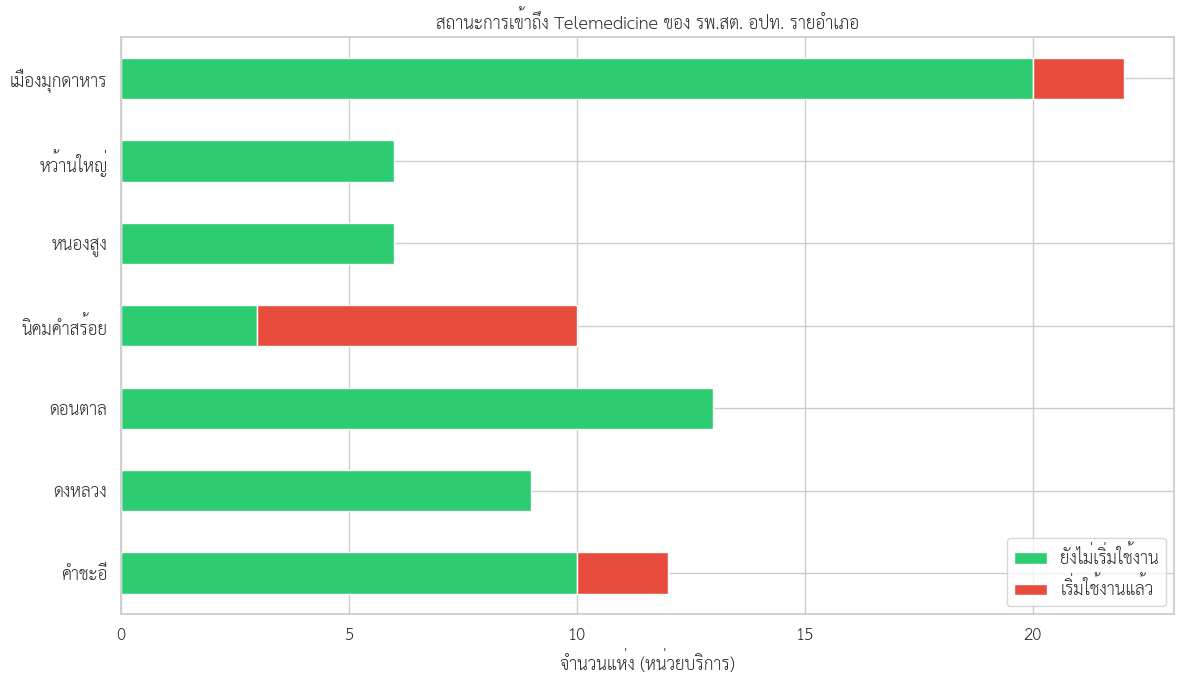

📌 จาก รพ.สต. อปท. ทั้งหมด 78 แห่ง
🚀 พบกลุ่มศักยภาพสูง (OP > 5,000 แต่ยังไม่ทำ Telemed): 0 แห่ง

📋 รายชื่อ 10 อันดับ รพ.สต. อปท. ศักยภาพสูง (ควรเร่งสนับสนุน):
Empty DataFrame
Columns: [hospname, AMP_NAME, OP69]
Index: []


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและกรองข้อมูล อปท. ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# --- 3. วิเคราะห์กลุ่ม "ศักยภาพสูงที่ยังไม่เริ่ม" (High OP, Zero Telemed) ---
# นิยาม: OP > 5,000 ครั้งต่อปี แต่ Telemed = 0
high_potential = lgo_df[(lgo_df['Telemed69'] == 0) & (lgo_df['OP69'] > 5000)].copy()
high_potential = high_potential[['hospname', 'AMP_NAME', 'OP69']].sort_values(by='OP69', ascending=False)

# --- 4. กราฟวิเคราะห์สัดส่วนรายอำเภอ (จำนวนหน่วยงานที่เริ่ม vs ยังไม่เริ่ม) ---
lgo_df['Status'] = lgo_df['Telemed69'].apply(lambda x: 'เริ่มใช้งานแล้ว' if x > 0 else 'ยังไม่เริ่มใช้งาน')
district_status = lgo_df.groupby(['AMP_NAME', 'Status']).size().unstack(fill_value=0).reset_index()

plt.figure(figsize=(12, 8))
district_status.set_index('AMP_NAME').plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c'], figsize=(12, 7))
plt.title('สถานะการเข้าถึง Telemedicine ของ รพ.สต. อปท. รายอำเภอ', fontsize=18, fontproperties=prop)
plt.legend(prop=prop)
plt.xlabel('จำนวนแห่ง (หน่วยบริการ)', fontproperties=prop)
plt.ylabel('')
plt.xticks(fontproperties=prop)
plt.yticks(fontproperties=prop)
plt.tight_layout()
plt.savefig('lgo_status_by_district.png')
plt.show()

# --- 5. แสดงผลรายงาน ---
print(f"📌 จาก รพ.สต. อปท. ทั้งหมด {len(lgo_df)} แห่ง")
print(f"🚀 พบกลุ่มศักยภาพสูง (OP > 5,000 แต่ยังไม่ทำ Telemed): {len(high_potential)} แห่ง")
print("\n📋 รายชื่อ 10 อันดับ รพ.สต. อปท. ศักยภาพสูง (ควรเร่งสนับสนุน):")
print(high_potential.head(10).to_string(index=False))

# เซฟไฟล์กลุ่มเป้าหมาย (Target List)
high_potential.to_csv('lgo_target_list_2570.csv', index=False, encoding='utf-8-sig')

In [40]:
import pandas as pd
import os

# --- 1. โหลดข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ อปท.
lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# --- 2. ตั้งเกณฑ์ (Benchmarks) ---
op_median = lgo_df['OP69'].median() # ค่ากลางของจำนวนผู้ป่วย
util_avg = (lgo_df['Telemed69'].sum() / lgo_df['OP69'].sum() * 100) if lgo_df['OP69'].sum() > 0 else 0

# --- 3. จัดกลุ่มหน่วยงาน (Segmentation) ---
def segment_unit(row):
    util = (row['Telemed69'] / row['OP69'] * 100) if row['OP69'] > 0 else 0
    if row['OP69'] >= op_median and util >= util_avg:
        return '1. Champions (ต้นแบบ)'
    elif row['OP69'] >= op_median and util < util_avg:
        return '2. Sleeping Giants (ศักยภาพสูงที่ต้องกระตุ้น)'
    elif row['OP69'] < op_median and util >= util_avg:
        return '3. Active Small (จิ๋วแต่แจ๋ว)'
    else:
        return '4. Waiting for Support (กลุ่มรอการสนับสนุน)'

lgo_df['Strategic_Group'] = lgo_df.apply(segment_unit, axis=1)

# --- 4. สรุปผลรายกลุ่ม ---
seg_summary = lgo_df.groupby('Strategic_Group').agg({
    'hospname': 'count',
    'OP69': 'sum',
    'Telemed69': 'sum'
}).reset_index()

# --- 5. คัดรายชื่อหน่วยงานสำคัญ (ไม่ต้องมีรหัส) ---
final_report = lgo_df[['hospname', 'AMP_NAME', 'OP69', 'Telemed69', 'Strategic_Group']].sort_values(by=['Strategic_Group', 'OP69'], ascending=[True, False])

# บันทึกไฟล์
final_report.to_csv('lgo_strategic_segmentation.csv', index=False, encoding='utf-8-sig')

print("📊 สรุปจำนวนหน่วยงาน อปท. แยกตามกลุ่มกลยุทธ์:")
print(seg_summary.to_string(index=False))

📊 สรุปจำนวนหน่วยงาน อปท. แยกตามกลุ่มกลยุทธ์:
                              Strategic_Group  hospname  OP69  Telemed69
                        1. Champions (ต้นแบบ)         3    38       0.89
2. Sleeping Giants (ศักยภาพสูงที่ต้องกระตุ้น)        75    11       0.18


/tmp/ipykernel_175/3807678009.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


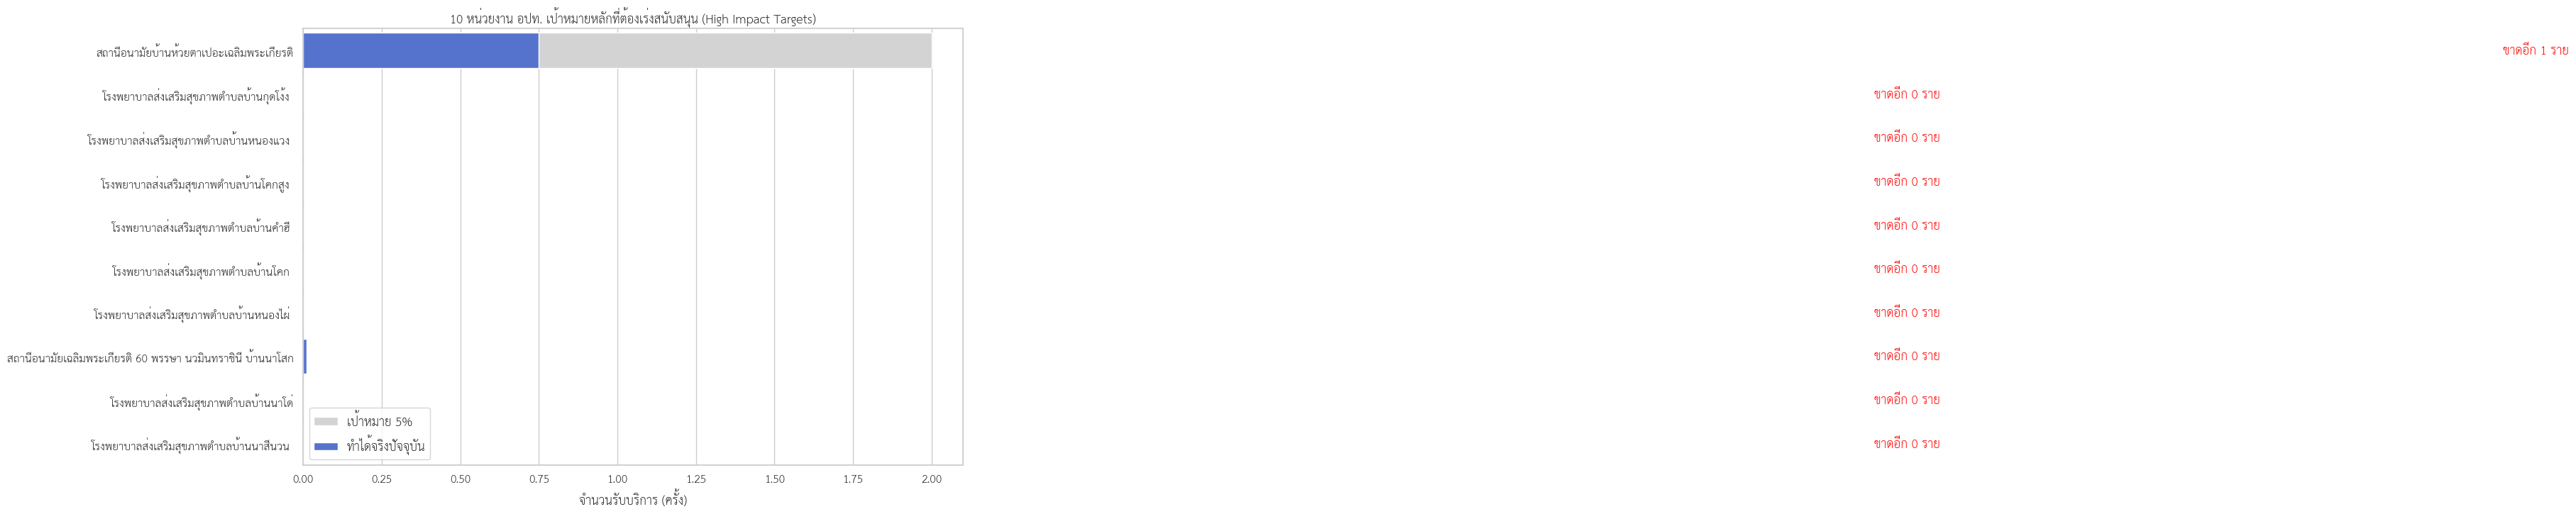

🚀 บัญชีรายชื่อ 10 หน่วยงาน อปท. ที่ส่งผลต่อเป้าหมายจังหวัดสูงสุด:
                                                  hospname      AMP_NAME  OP69  Telemed69  เป้าหมาย (5%)  จำนวนที่ยังขาด (Gap)
                  สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ        คำชะอี    33       0.75            2.0                  1.25
                   โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านกุดโง้ง  เมืองมุกดาหาร     0       0.00            0.0                  0.00
                   โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านหนองแวง  เมืองมุกดาหาร     0       0.00            0.0                  0.00
                    โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านโคกสูง  เมืองมุกดาหาร     0       0.00            0.0                  0.00
                      โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านคำฮี  เมืองมุกดาหาร     0       0.00            0.0                  0.00
                       โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านโคก  เมืองมุกดาหาร     0       0.00            0.0                  0.00
                   โรงพยาบาลส่งเสริมสุขภาพตำบ

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ อปท.
lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# --- 3. คำนวณเป้าหมายร้อยละ 5 (Target Gap) ---
target_rate = 0.05 # 5%
lgo_df['เป้าหมาย (5%)'] = (lgo_df['OP69'] * target_rate).round(0)
lgo_df['จำนวนที่ยังขาด (Gap)'] = (lgo_df['เป้าหมาย (5%)'] - lgo_df['Telemed69']).clip(lower=0)
lgo_df['% ปัจจุบัน'] = (lgo_df['Telemed69'] / lgo_df['OP69'] * 100).fillna(0)

# คัด 10 อันดับที่ "ต้องเติมเคส" มากที่สุด (High Impact)
priority_targets = lgo_df.sort_values(by='จำนวนที่ยังขาด (Gap)', ascending=False).head(10)

# --- 4. วาดกราฟวิเคราะห์ "ศักยภาพที่ซ่อนอยู่" ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", font=font_name)

# กราฟแสดงระยะห่างระหว่าง "ยอดปัจจุบัน" กับ "เป้าหมาย 5%"
ax = sns.barplot(data=priority_targets, x='เป้าหมาย (5%)', y='hospname', color='lightgrey', label='เป้าหมาย 5%')
sns.barplot(data=priority_targets, x='Telemed69', y='hospname', color='royalblue', label='ทำได้จริงปัจจุบัน')

plt.title('10 หน่วยงาน อปท. เป้าหมายหลักที่ต้องเร่งสนับสนุน (High Impact Targets)', 
          fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนรับบริการ (ครั้ง)', fontproperties=prop)
plt.ylabel('')
plt.legend(prop=prop)

# ใส่ตัวเลขจำนวนที่ยังขาด (Gap) กำกับท้ายแท่ง
for i, gap in enumerate(priority_targets['จำนวนที่ยังขาด (Gap)']):
    plt.text(priority_targets['เป้าหมาย (5%)'].iloc[i] + 5, i, f"ขาดอีก {gap:,.0f} ราย", 
             va='center', color='red', fontweight='bold', fontproperties=prop)

plt.tight_layout()
plt.savefig('lgo_priority_impact_list.png', dpi=300)
plt.show()

# --- 5. บันทึกและแสดงตาราง ---
print("🚀 บัญชีรายชื่อ 10 หน่วยงาน อปท. ที่ส่งผลต่อเป้าหมายจังหวัดสูงสุด:")
print(priority_targets[['hospname', 'AMP_NAME', 'OP69', 'Telemed69', 'เป้าหมาย (5%)', 'จำนวนที่ยังขาด (Gap)']].to_string(index=False))

# เซฟไฟล์รายชื่อส่งให้ผู้บริหาร
priority_targets.to_csv('lgo_priority_action_list.csv', index=False, encoding='utf-8-sig')

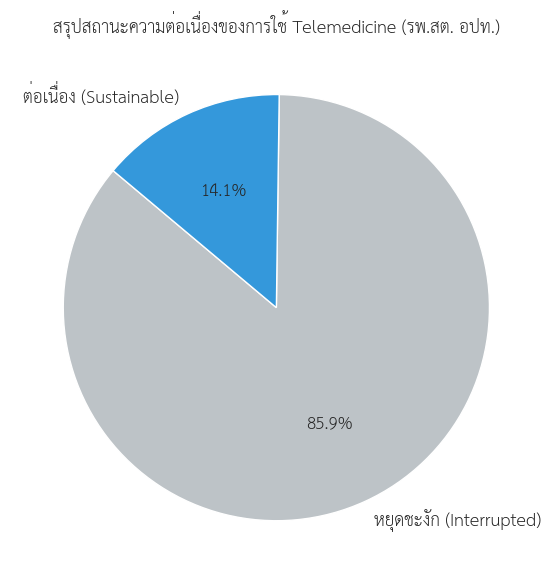

🌟 รายชื่อ รพ.สต. อปท. กลุ่ม Rising Stars (เริ่มใช้งานปี 2569 ได้อย่างโดดเด่น):
Empty DataFrame
Columns: [hospname, AMP_NAME, Telemed69]
Index: []


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['Telemed68', 'Telemed69', 'OP69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะกลุ่ม อปท.
lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# คำนวณการเปลี่ยนแปลง (Growth/Drop)
lgo_df['Diff'] = lgo_df['Telemed69'] - lgo_df['Telemed68']

# --- 3. จัดกลุ่มตามความสม่ำเสมอ ---
def check_consistency(row):
    if row['Telemed68'] > 0 and row['Telemed69'] > 0:
        return 'ต่อเนื่อง (Sustainable)'
    elif row['Telemed68'] == 0 and row['Telemed69'] > 0:
        return 'หน้าใหม่ (New Entry)'
    elif row['Telemed68'] > 0 and row['Telemed69'] == 0:
        return 'หยุดชะงัก (Interrupted)'
    else:
        return 'ยังไม่เริ่ม (Inactive)'

lgo_df['Consistency_Status'] = lgo_df.apply(check_consistency, axis=1)

# --- 4. กราฟสรุปสถานะความต่อเนื่องภาพรวม อปท. ---
plt.figure(figsize=(10, 6))
status_counts = lgo_df['Consistency_Status'].value_counts()
colors = ['#bdc3c7', '#3498db', '#2ecc71', '#e74c3c']

plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, textprops={'fontproperties': prop, 'fontsize': 12})
plt.title('สรุปสถานะความต่อเนื่องของการใช้ Telemedicine (รพ.สต. อปท.)', 
          fontsize=16, fontweight='bold', fontproperties=prop)
plt.tight_layout()
plt.savefig('lgo_consistency_pie.png')
plt.show()

# --- 5. คัดรายชื่อหน่วยงานกลุ่ม Rising Stars (หน้าใหม่แรงดันสูง) ---
rising_stars = lgo_df[lgo_df['Consistency_Status'] == 'หน้าใหม่ (New Entry)'].sort_values(by='Telemed69', ascending=False)

print("🌟 รายชื่อ รพ.สต. อปท. กลุ่ม Rising Stars (เริ่มใช้งานปี 2569 ได้อย่างโดดเด่น):")
print(rising_stars[['hospname', 'AMP_NAME', 'Telemed69']].head(10).to_string(index=False))

# เซฟไฟล์รายงานความต่อเนื่อง
lgo_df[['hospname', 'AMP_NAME', 'Telemed68', 'Telemed69', 'Consistency_Status']].to_csv('lgo_consistency_report.csv', index=False, encoding='utf-8-sig')

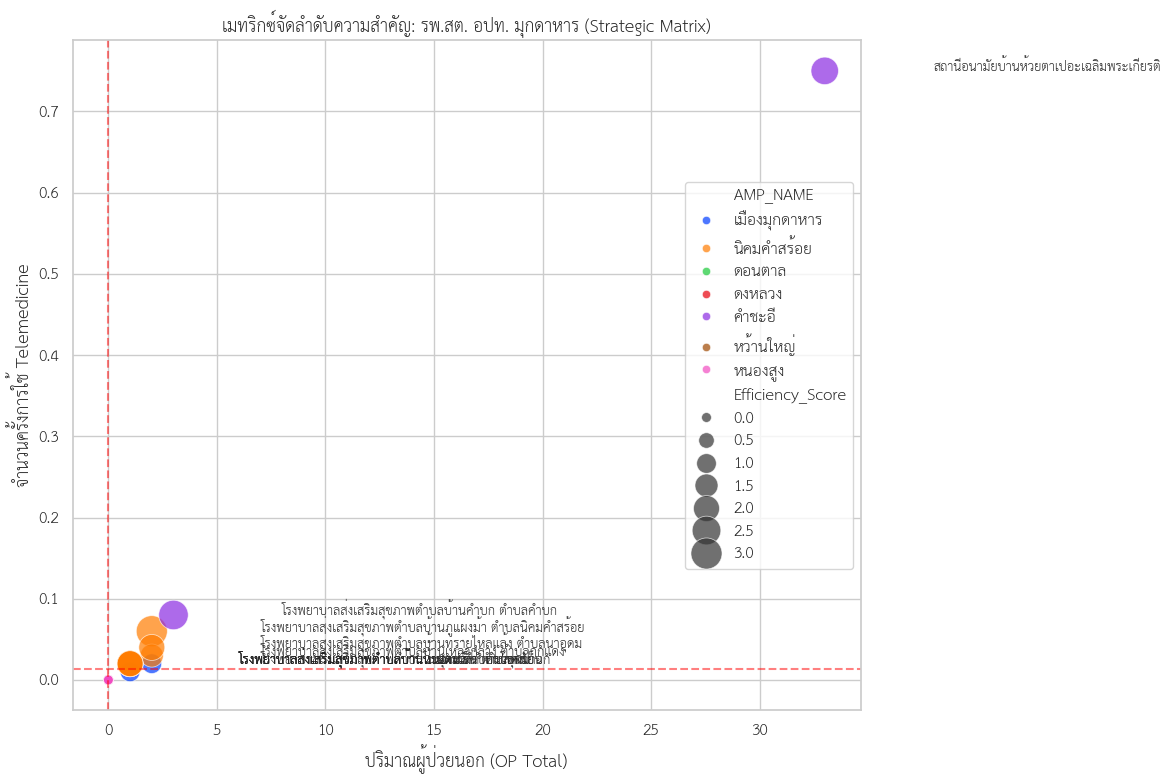

🚀 บัญชีรายชื่อหน่วยงาน อปท. ที่ควรเริ่มโครงการนำร่อง (High Priority):
                                               hospname      AMP_NAME  OP69  Telemed69  Efficiency_Score
               สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ        คำชะอี    33       0.75          2.272727
           โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านคำบก ตำบลคำบก        คำชะอี     3       0.08          2.666667
โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านภูแผงม้า ตำบลนิคมคำสร้อย   นิคมคำสร้อย     2       0.06          3.000000
  โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านทรายไหลแล้ง ตำบลนาอุดม   นิคมคำสร้อย     2       0.04          2.000000
     โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านเหล่ากลาง ตำบลกกแดง   นิคมคำสร้อย     2       0.03          1.500000
       โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านดงเย็น ตำบลดงเย็น เมืองมุกดาหาร     2       0.02          1.000000
                โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านหนองแวง    นิคมคำสร้อย     1       0.02          2.000000
       โรงพยาบาลส่งเสริมสุขภาพตำบลบ้านนาอุดม ตำบลนาอุดม   นิคมคำสร้อย     1       0.02    

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะกลุ่ม อปท.
lgo_df = df[df['M_NAME'] == 'องค์กรปกครองส่วนท้องถิ่น'].copy()

# คำนวณคะแนนประสิทธิภาพ (Efficiency Score)
lgo_df['Efficiency_Score'] = (lgo_df['Telemed69'] / lgo_df['OP69'] * 100).fillna(0)

# --- 3. สร้าง Prioritization Matrix ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", font=font_name)

# คำนวณค่ากลางเพื่อแบ่ง Quadrant
op_threshold = lgo_df['OP69'].median()
tele_threshold = lgo_df['Telemed69'].mean()

# วาดกราฟ Scatter Plot
ax = sns.scatterplot(data=lgo_df, x='OP69', y='Telemed69', size='Efficiency_Score', 
                     hue='AMP_NAME', palette='bright', sizes=(50, 500), alpha=0.7)

# ขีดเส้นแบ่ง Quadrant
plt.axvline(op_threshold, color='red', linestyle='--', alpha=0.5)
plt.axhline(tele_threshold, color='red', linestyle='--', alpha=0.5)

plt.title('เมทริกซ์จัดลำดับความสำคัญ: รพ.สต. อปท. มุกดาหาร (Strategic Matrix)', 
          fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('ปริมาณผู้ป่วยนอก (OP Total)', fontproperties=prop)
plt.ylabel('จำนวนครั้งการใช้ Telemedicine', fontproperties=prop)

# ใส่ชื่อเฉพาะหน่วยงานที่มียอด Telemed สูง (เพื่อไม่ให้กราฟรก)
for i in range(lgo_df.shape[0]):
    if lgo_df.Telemed69.iloc[i] > 0.01:
        plt.text(lgo_df.OP69.iloc[i]+5, lgo_df.Telemed69.iloc[i], 
                 lgo_df.hospname.iloc[i], fontsize=9, fontproperties=prop)

plt.tight_layout()
plt.savefig('lgo_strategic_matrix.png', dpi=300)
plt.show()

# --- 4. แสดงตารางลำดับความสำคัญสูงสุด ---
print("🚀 บัญชีรายชื่อหน่วยงาน อปท. ที่ควรเริ่มโครงการนำร่อง (High Priority):")
priority_list = lgo_df.sort_values(by=['Telemed69', 'OP69'], ascending=False).head(10)
print(priority_list[['hospname', 'AMP_NAME', 'OP69', 'Telemed69', 'Efficiency_Score']].to_string(index=False))

# เซฟไฟล์สุดท้ายของบทสรุป อปท.
priority_list.to_csv('lgo_priority_final_report.csv', index=False, encoding='utf-8-sig')

เปรียบเทียบ สังกัด กระทรวงสาธารณสุข และ สังกัด อปท.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')

# แปลงคอลัมน์ที่เกี่ยวข้องให้เป็นตัวเลข
cols_to_fix = ['OP68', 'Telemed68', 'OP69', 'Telemed69']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ 2 สังกัดที่ต้องการเปรียบเทียบ
df_compare = df[df['M_NAME'].isin(['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น'])].copy()

# --- 3. สรุปข้อมูลตามสังกัด (Aggregation) ---
summary = df_compare.groupby('M_NAME').agg({
    'hospcode': 'count',
    'OP68': 'sum',
    'Telemed68': 'sum',
    'OP69': 'sum',
    'Telemed69': 'sum'
}).reset_index()

summary.columns = ['สังกัด', 'จำนวนหน่วยงาน', 'OP_2568', 'Telemed_2568', 'OP_2569', 'Telemed_2569']

# คำนวณร้อยละการเข้าถึง (Utilization Rate)
summary['ร้อยละการเข้าถึง (ปี 68)'] = (summary['Telemed_2568'] / summary['OP_2568'] * 100).fillna(0)
summary['ร้อยละการเข้าถึง (ปี 69)'] = (summary['Telemed_2569'] / summary['OP_2569'] * 100).fillna(0)

# --- 4. แสดงผลตารางสรุป ---
print("📊 รายงานเปรียบเทียบผลงาน Telemedicine ตามสังกัด (ปี 2568-2569):")
print(summary.to_string(index=False))

# บันทึกไฟล์สรุป
summary.to_csv('affiliation_comparison_final.csv', index=False, encoding='utf-8-sig')

📊 รายงานเปรียบเทียบผลงาน Telemedicine ตามสังกัด (ปี 2568-2569):
                  สังกัด  จำนวนหน่วยงาน  OP_2568  Telemed_2568  OP_2569  Telemed_2569  ร้อยละการเข้าถึง (ปี 68)  ร้อยละการเข้าถึง (ปี 69)
        กระทรวงสาธารณสุข              7   703404         14183   391664       8828.00              2.016338e+00                  2.253973
องค์กรปกครองส่วนท้องถิ่น             78        4        499273       49          1.07              1.248182e+07                  2.183673


✅ ติดตั้งฟอนต์สำเร็จ: TH Sarabun New


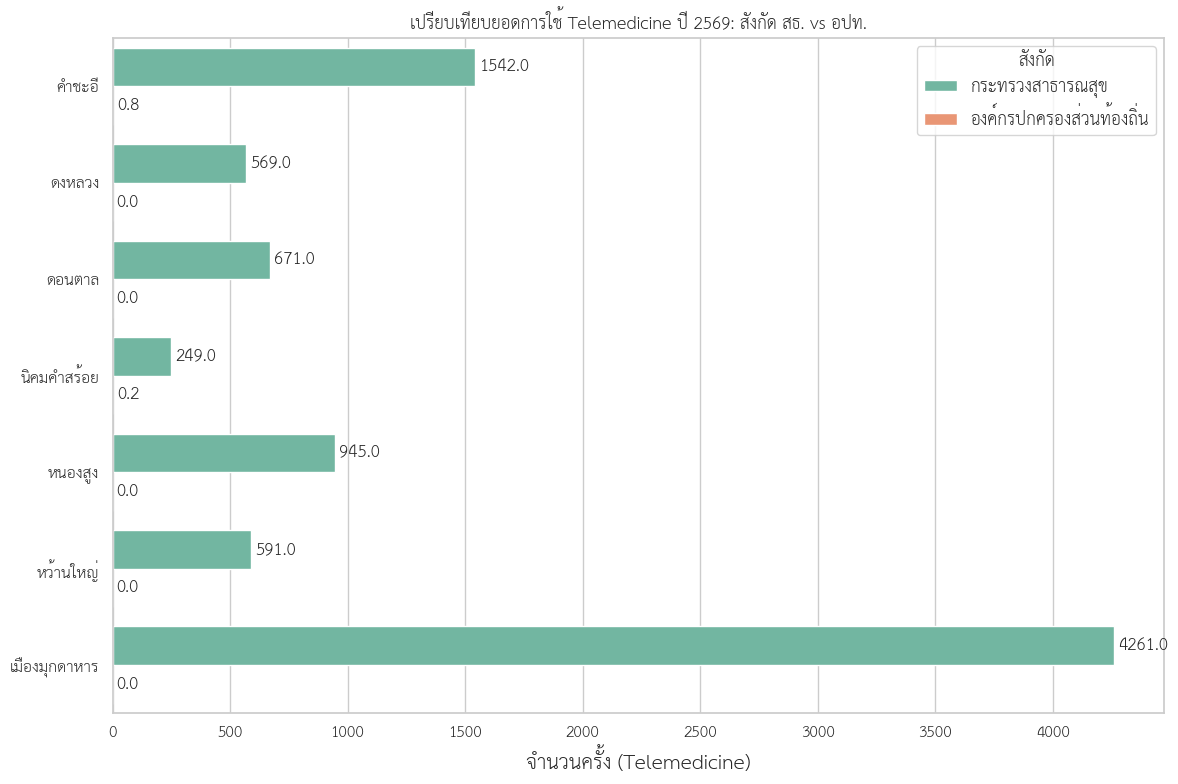


📊 ตารางเปรียบเทียบยอด Telemedicine (ครั้ง) รายอำเภอ:
M_NAME         กระทรวงสาธารณสุข  องค์กรปกครองส่วนท้องถิ่น
อำเภอ                                                    
คำชะอี                   1542.0                      0.83
ดงหลวง                    569.0                      0.00
ดอนตาล                    671.0                      0.00
นิคมคำสร้อย               249.0                      0.21
หนองสูง                   945.0                      0.00
หว้านใหญ่                 591.0                      0.00
เมืองมุกดาหาร            4261.0                      0.03

✅ บันทึกไฟล์รายงานเปรียบเทียบที่: comparison_report_moph_lgo.csv


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย (แก้ไข Path ให้ตรงกับระบบของคุณ) ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False
    prop = fm.FontProperties(fname=font_path)
    print(f"✅ ติดตั้งฟอนต์สำเร็จ: {font_name}")
else:
    font_name = 'sans-serif'
    prop = None
    print("⚠️ ไม่พบฟอนต์ภาษาไทย กราฟอาจแสดงผลเป็นสี่เหลี่ยม")

# --- 2. โหลดและเตรียมข้อมูล ---
file_path = 'telemed_hosp_final.csv'
if not os.path.exists(file_path):
    print(f"❌ ไม่พบไฟล์ {file_path}")
else:
    df = pd.read_csv(file_path)

    # แปลงคอลัมน์ตัวเลขให้พร้อมคำนวณ
    cols_to_fix = ['OP69', 'Telemed69']
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # กรองเฉพาะ 2 สังกัดที่ต้องการเปรียบเทียบ
    target_m = ['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น']
    df_filtered = df[df['M_NAME'].isin(target_m)].copy()

    # --- 3. สรุปข้อมูลรายอำเภอแยกตามสังกัด ---
    # ใช้ AMP_NAME และ M_NAME เป็นหลักในการ Group
    dist_m_summary = df_filtered.groupby(['AMP_NAME', 'M_NAME']).agg({
        'Telemed69': 'sum',
        'OP69': 'sum'
    }).reset_index()

    # คำนวณร้อยละการเข้าถึง
    dist_m_summary['Access_Rate'] = (dist_m_summary['Telemed69'] / dist_m_summary['OP69'] * 100).fillna(0)

    # --- 4. วาดกราฟเปรียบเทียบ (Bar Chart) ---
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid", font=font_name)

    # วาดกราฟเปรียบเทียบยอด Telemedicine
    ax = sns.barplot(data=dist_m_summary, x='Telemed69', y='AMP_NAME', hue='M_NAME', palette='Set2')

    plt.title('เปรียบเทียบยอดการใช้ Telemedicine ปี 2569: สังกัด สธ. vs อปท.', 
              fontsize=18, fontweight='bold', fontproperties=prop)
    plt.xlabel('จำนวนครั้ง (Telemedicine)', fontsize=14, fontproperties=prop)
    plt.ylabel('')
    plt.legend(title='สังกัด', prop=prop)

    # ใส่ตัวเลขท้ายแท่งกราฟ (บังคับฟอนต์ไทย)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%.1f', fontproperties=prop)

    plt.tight_layout()
    plt.savefig('comparison_moph_lgo_district.png', dpi=300)
    plt.show()

    # --- 5. สร้างตารางเปรียบเทียบแบบ Side-by-Side (Pivot Table) ---
    comparison_pivot = dist_m_summary.pivot(index='AMP_NAME', columns='M_NAME', values='Telemed69').fillna(0)
    
    # เปลี่ยนชื่อ Index ให้เป็นภาษาไทยเพื่อการแสดงผล
    comparison_pivot.index.name = 'อำเภอ'
    
    print("\n📊 ตารางเปรียบเทียบยอด Telemedicine (ครั้ง) รายอำเภอ:")
    print(comparison_pivot)

    # เซฟไฟล์รายงานสรุปเปรียบเทียบ
    comparison_pivot.to_csv('comparison_report_moph_lgo.csv', encoding='utf-8-sig')
    print("\n✅ บันทึกไฟล์รายงานเปรียบเทียบที่: comparison_report_moph_lgo.csv")

In [46]:
# --- Top 10 Overall Leaderboard ---
# รวมทุกสังกัดเข้าด้วยกัน
overall_top = df[['hospname', 'M_NAME', 'Telemed69', 'OP69']].copy()
overall_top['%_Access'] = (overall_top['Telemed69'] / overall_top['OP69'] * 100).fillna(0)
overall_top = overall_top.sort_values(by='Telemed69', ascending=False).head(10)

print("🏆 10 อันดับหน่วยงานที่มีจำนวนการใช้ Telemedicine สูงสุด (Overall):")
print(overall_top.to_string(index=False))

🏆 10 อันดับหน่วยงานที่มีจำนวนการใช้ Telemedicine สูงสุด (Overall):
                                               hospname                   M_NAME  Telemed69   OP69  %_Access
                                      โรงพยาบาลมุกดาหาร         กระทรวงสาธารณสุข    4261.00 168446  2.529594
                                        โรงพยาบาลคำชะอี         กระทรวงสาธารณสุข    1542.00  49067  3.142642
                                       โรงพยาบาลหนองสูง         กระทรวงสาธารณสุข     945.00  34631  2.728769
                                        โรงพยาบาลดอนตาล         กระทรวงสาธารณสุข     671.00  38828  1.728134
                                     โรงพยาบาลหว้านใหญ่         กระทรวงสาธารณสุข     591.00  26032  2.270283
                                        โรงพยาบาลดงหลวง         กระทรวงสาธารณสุข     569.00  28175  2.019521
                                   โรงพยาบาลนิคมคำสร้อย         กระทรวงสาธารณสุข     249.00  46485  0.535657
               สถานีอนามัยบ้านห้วยตาเปอะเฉลิมพระเกียรติ องค์ก

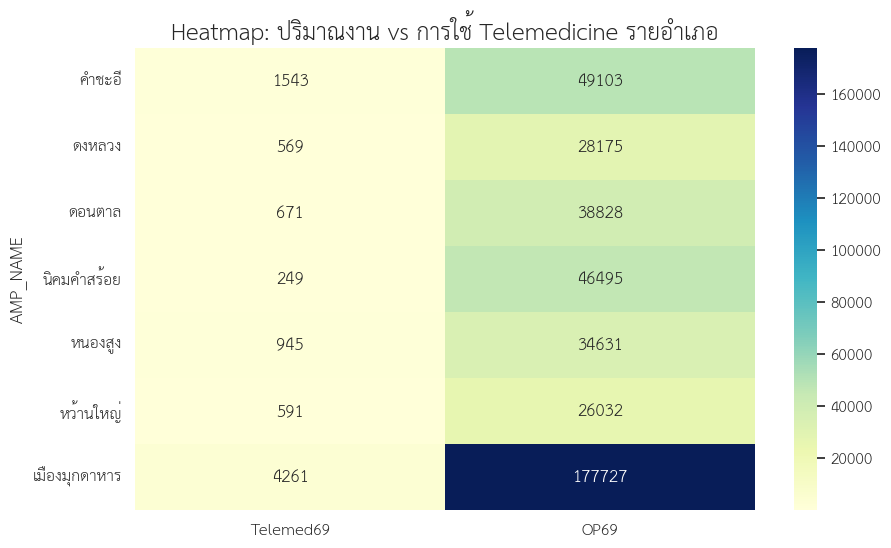

In [47]:
# --- Heatmap Style Table ---
# เปรียบเทียบระหว่างปริมาณผู้ป่วย (OP) และการใช้ Telemed รายอำเภอ
heatmap_data = df.groupby('AMP_NAME').agg({
    'OP69': 'sum',
    'Telemed69': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data.set_index('AMP_NAME')[['Telemed69', 'OP69']], 
            annot=True, fmt=".0f", cmap="YlGnBu", cbar=True)
plt.title('Heatmap: ปริมาณงาน vs การใช้ Telemedicine รายอำเภอ', fontproperties=prop, fontsize=16)
plt.show()

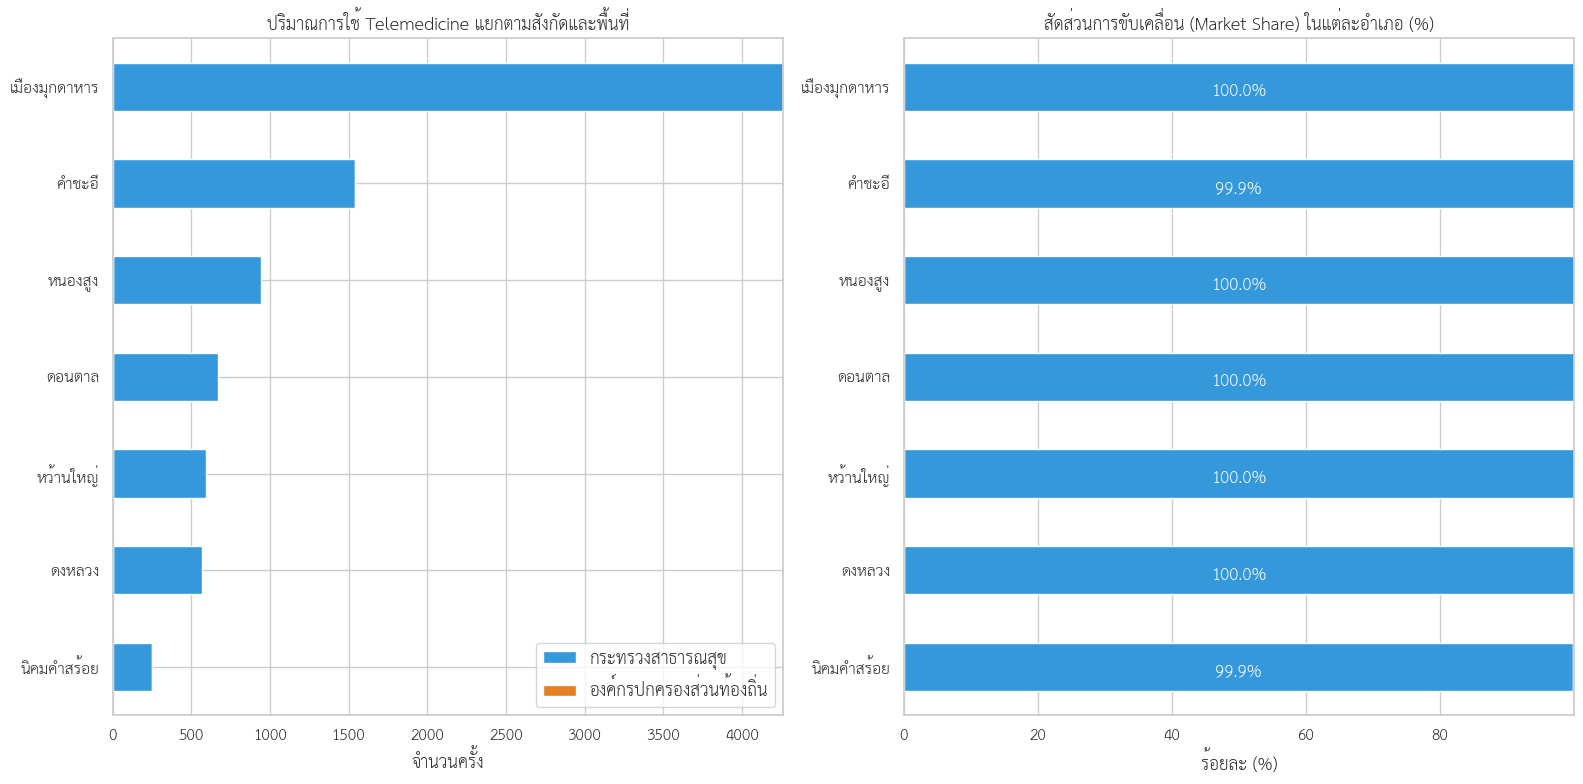

📊 สรุปสัดส่วนการให้บริการรายอำเภอ (สธ. vs อปท.):
M_NAME         กระทรวงสาธารณสุข  องค์กรปกครองส่วนท้องถิ่น
AMP_NAME                                                 
นิคมคำสร้อย           99.915734                  0.084266
คำชะอี                99.946203                  0.053797
เมืองมุกดาหาร         99.999296                  0.000704
หว้านใหญ่            100.000000                  0.000000
ดงหลวง               100.000000                  0.000000
หนองสูง              100.000000                  0.000000
ดอนตาล               100.000000                  0.000000


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. จัดการฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. เตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ 2 สังกัดหลัก
df_comp = df[df['M_NAME'].isin(['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น'])].copy()

# --- 3. สรุปข้อมูลรายอำเภอแบบสแต็ก (Stacked Data) ---
dist_summary = df_comp.groupby(['AMP_NAME', 'M_NAME'])['Telemed69'].sum().unstack().fillna(0)
dist_summary['Total'] = dist_summary.sum(axis=1)
dist_summary = dist_summary.sort_values(by='Total', ascending=True) # เรียงจากยอดรวม

# --- 4. สร้าง Dashboard เปรียบเทียบรายพื้นที่ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
sns.set_theme(style="whitegrid", font=font_name)

# กราฟ 1: จำนวนเคสสะสม (Volume Stacked Bar)
dist_summary[['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น']].plot(
    kind='barh', stacked=True, ax=ax1, color=['#3498db', '#e67e22']
)
ax1.set_title('ปริมาณการใช้ Telemedicine แยกตามสังกัดและพื้นที่', fontsize=16, fontproperties=prop)
ax1.set_xlabel('จำนวนครั้ง', fontproperties=prop)
ax1.set_ylabel('')
ax1.legend(prop=prop)

# กราฟ 2: ร้อยละการครองส่วนแบ่งในพื้นที่ (Percent Contribution)
dist_pct = dist_summary[['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น']].div(dist_summary['Total'], axis=0) * 100
dist_pct.plot(kind='barh', stacked=True, ax=ax2, color=['#3498db', '#e67e22'], legend=False)
ax2.set_title('สัดส่วนการขับเคลื่อน (Market Share) ในแต่ละอำเภอ (%)', fontsize=16, fontproperties=prop)
ax2.set_xlabel('ร้อยละ (%)', fontproperties=prop)
ax2.set_ylabel('')

# ใส่ตัวเลข % กำกับในกราฟ 2
for p in ax2.patches:
    width = p.get_width()
    if width > 5: # แสดงตัวเลขเฉพาะแท่งที่กว้างพอ
        ax2.annotate(f'{width:.1f}%', (p.get_x() + width/2, p.get_y() + 0.15), 
                     ha='center', color='white', fontweight='bold', fontproperties=prop)

plt.tight_layout()
plt.savefig('moph_vs_lgo_area_dashboard.png', dpi=300)
plt.show()

# --- 5. สรุปตารางรายงาน ---
print("📊 สรุปสัดส่วนการให้บริการรายอำเภอ (สธ. vs อปท.):")
print(dist_pct.sort_values(by='องค์กรปกครองส่วนท้องถิ่น', ascending=False).to_string())

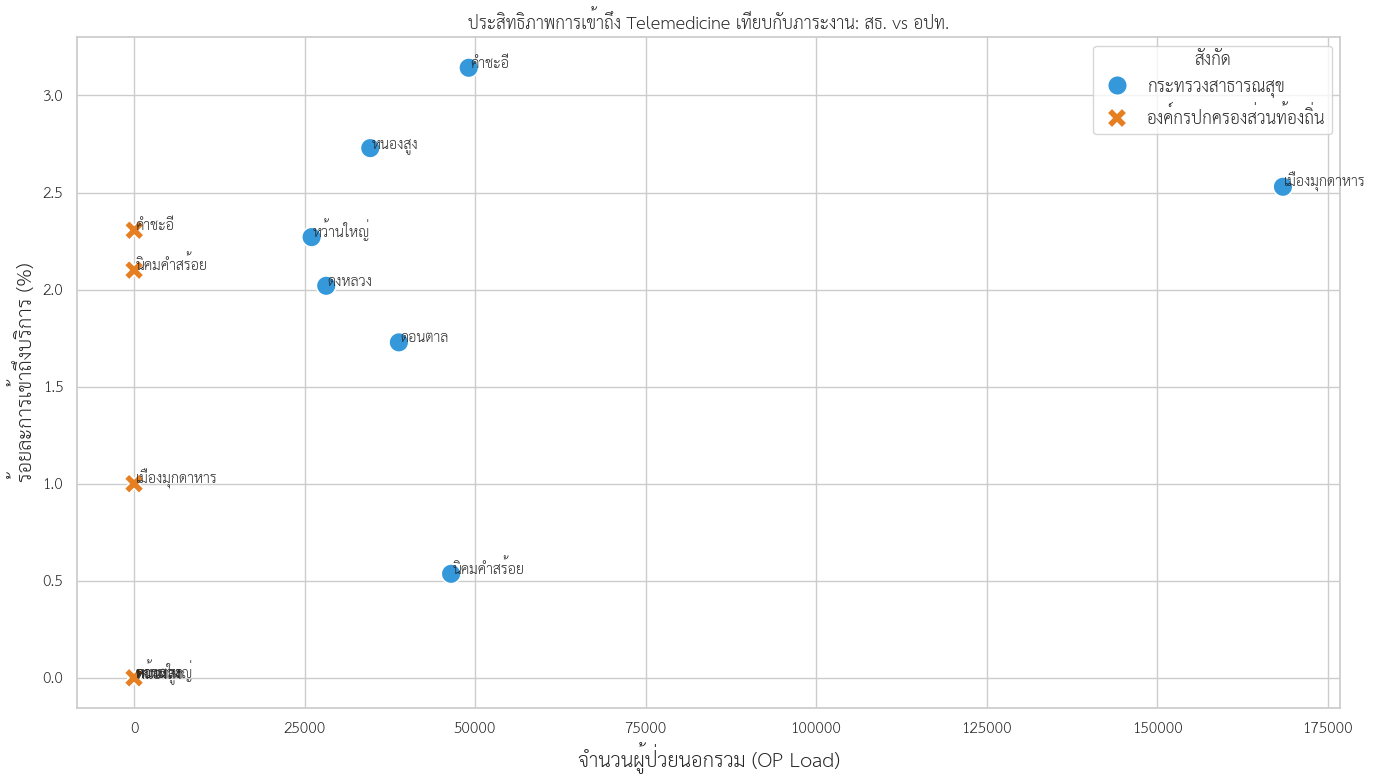

📊 ตารางเปรียบเทียบประสิทธิภาพเครือข่ายรายอำเภอ:
------------------------------------------------------------------------------------------
     AMP_NAME                   M_NAME  hospcode   OP69  Telemed69  Efficiency (%)
       คำชะอี         กระทรวงสาธารณสุข         1  49067    1542.00        3.142642
       คำชะอี องค์กรปกครองส่วนท้องถิ่น        12     36       0.83        2.305556
       ดงหลวง         กระทรวงสาธารณสุข         1  28175     569.00        2.019521
       ดงหลวง องค์กรปกครองส่วนท้องถิ่น         9      0       0.00        0.000000
       ดอนตาล         กระทรวงสาธารณสุข         1  38828     671.00        1.728134
       ดอนตาล องค์กรปกครองส่วนท้องถิ่น        13      0       0.00        0.000000
  นิคมคำสร้อย         กระทรวงสาธารณสุข         1  46485     249.00        0.535657
  นิคมคำสร้อย องค์กรปกครองส่วนท้องถิ่น        10     10       0.21        2.100000
      หนองสูง         กระทรวงสาธารณสุข         1  34631     945.00        2.728769
      หนองสูง องค์กรปกครองส่วนท

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. การตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. เตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ 2 สังกัดหลัก
df_comp = df[df['M_NAME'].isin(['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น'])].copy()

# --- 3. วิเคราะห์ประสิทธิภาพรายอำเภอ ---
dist_eff = df_comp.groupby(['AMP_NAME', 'M_NAME']).agg({
    'hospcode': 'count',
    'OP69': 'sum',
    'Telemed69': 'sum'
}).reset_index()

dist_eff['Efficiency (%)'] = (dist_eff['Telemed69'] / dist_eff['OP69'] * 100).fillna(0)

# --- 4. สร้าง Dashboard เปรียบเทียบประสิทธิภาพ ---
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid", font=font_name)

# ใช้ Scatter Plot เพื่อดูความสัมพันธ์ระหว่าง OP (ภาระงาน) และ Efficiency (ประสิทธิภาพ)
ax = sns.scatterplot(data=dist_eff, x='OP69', y='Efficiency (%)', 
                     hue='M_NAME', style='M_NAME', s=200, palette=['#3498db', '#e67e22'])

# ใส่ชื่ออำเภอกำกับที่จุด
for i in range(dist_eff.shape[0]):
    plt.text(dist_eff.OP69.iloc[i]+200, dist_eff['Efficiency (%)'].iloc[i], 
             dist_eff.AMP_NAME.iloc[i], fontsize=10, fontproperties=prop)

plt.title('ประสิทธิภาพการเข้าถึง Telemedicine เทียบกับภาระงาน: สธ. vs อปท.', 
          fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนผู้ป่วยนอกรวม (OP Load)', fontsize=14, fontproperties=prop)
plt.ylabel('ร้อยละการเข้าถึงบริการ (%)', fontsize=14, fontproperties=prop)
plt.legend(title='สังกัด', prop=prop)

plt.tight_layout()
plt.savefig('efficiency_comparison_scatter.png', dpi=300)
plt.show()

# --- 5. สรุปตารางเปรียบเทียบดัชนีประสิทธิภาพ ---
print("📊 ตารางเปรียบเทียบประสิทธิภาพเครือข่ายรายอำเภอ:")
print("-" * 90)
print(dist_eff.sort_values(by=['AMP_NAME', 'M_NAME']).to_string(index=False))

# เซฟไฟล์รายงาน
dist_eff.to_csv('district_efficiency_comparison.csv', index=False, encoding='utf-8-sig')

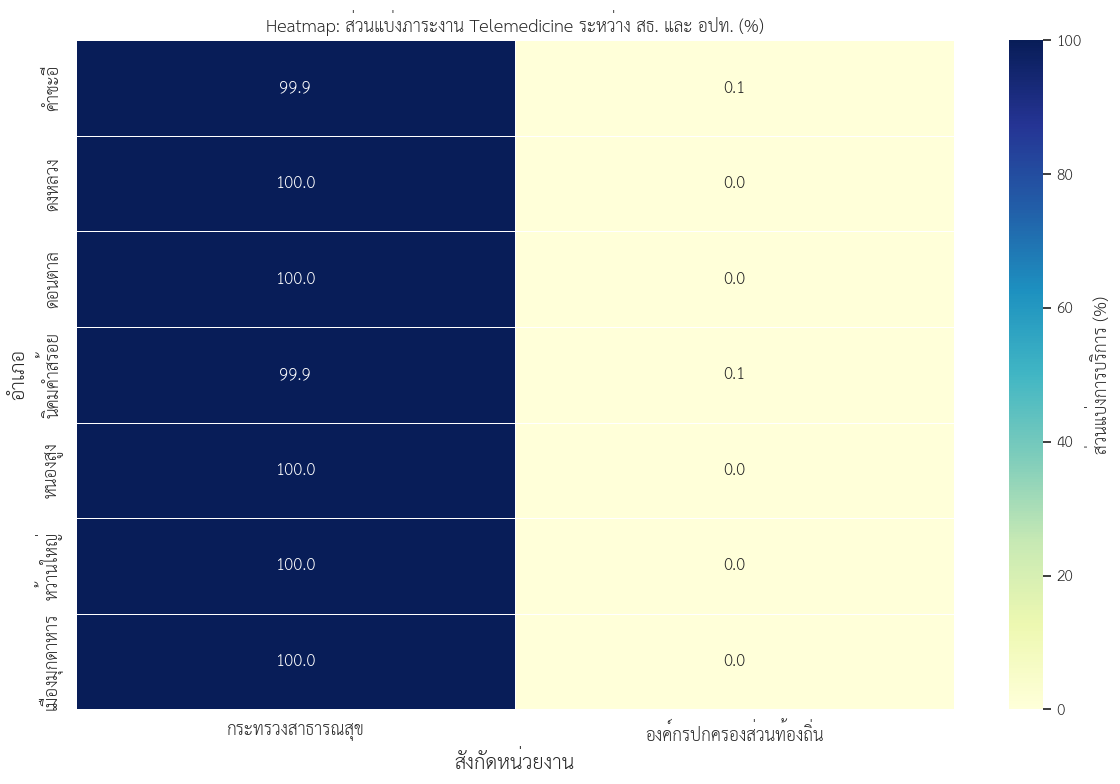

📊 ตารางวิเคราะห์ส่วนแบ่งภาระงาน (Contribution Share):
----------------------------------------------------------------------
M_NAME         กระทรวงสาธารณสุข  องค์กรปกครองส่วนท้องถิ่น
AMP_NAME                                                 
นิคมคำสร้อย               99.92                      0.08
คำชะอี                    99.95                      0.05
เมืองมุกดาหาร            100.00                      0.00
ดอนตาล                   100.00                      0.00
ดงหลวง                   100.00                      0.00
หนองสูง                  100.00                      0.00
หว้านใหญ่                100.00                      0.00


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# กรองเฉพาะ 2 สังกัดหลัก
df_filtered = df[df['M_NAME'].isin(['กระทรวงสาธารณสุข', 'องค์กรปกครองส่วนท้องถิ่น'])].copy()

# --- 3. สร้าง Pivot Table เพื่อทำ Heatmap ---
# แสดงจำนวน Telemedicine รวมรายอำเภอแยกตามสังกัด
heatmap_data = df_filtered.pivot_table(
    index='AMP_NAME', 
    columns='M_NAME', 
    values='Telemed69', 
    aggfunc='sum'
).fillna(0)

# คำนวณส่วนแบ่งการตลาด (Market Share %) ของแต่ละสังกัดในอำเภอนั้นๆ
share_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100
share_data = share_data.fillna(0)

# --- 4. วาด Dashboard เปรียบเทียบเชิงสัดส่วน ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="white", font=font_name)

# สร้าง Heatmap แสดงร้อยละส่วนแบ่งภาระงาน
ax = sns.heatmap(share_data, annot=True, fmt=".1f", cmap="YlGnBu", 
                 linewidths=.5, cbar_kws={'label': 'ส่วนแบ่งการบริการ (%)'})

plt.title('Heatmap: ส่วนแบ่งภาระงาน Telemedicine ระหว่าง สธ. และ อปท. (%)', 
          fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('สังกัดหน่วยงาน', fontsize=14, fontproperties=prop)
plt.ylabel('อำเภอ', fontsize=14, fontproperties=prop)

# ปรับ Font ของ Ticks
plt.xticks(fontproperties=prop, fontsize=12)
plt.yticks(fontproperties=prop, fontsize=12)

plt.tight_layout()
plt.savefig('moph_vs_lgo_share_heatmap.png', dpi=300)
plt.show()

# --- 5. สรุปตารางดัชนีความร่วมมือ (Cooperation Index) ---
print("📊 ตารางวิเคราะห์ส่วนแบ่งภาระงาน (Contribution Share):")
print("-" * 70)
print(share_data.sort_values(by='องค์กรปกครองส่วนท้องถิ่น', ascending=False).round(2).to_string())

# บันทึกไฟล์ข้อมูล
share_data.to_csv('district_service_share_report.csv', encoding='utf-8-sig')

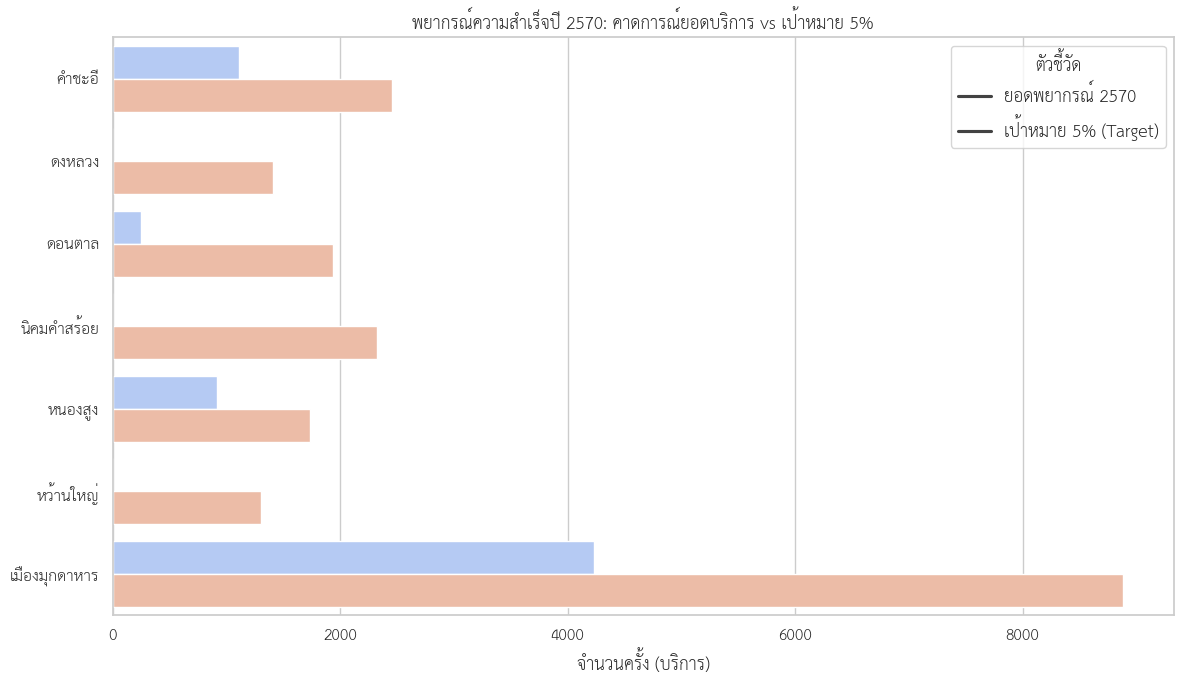

🚨 ตรวจพบหน่วยงานที่มีข้อมูลผิดปกติ (Util Rate > 50% - โปรดตรวจสอบใน HDC):
Empty DataFrame
Columns: [hospname, AMP_NAME, M_NAME, OP69, Telemed69, Util_Rate]
Index: []

📈 สรุปพยากรณ์ความสำเร็จรายอำเภอ (2570 Forecast):
     AMP_NAME  Forecast_2570  Target_2570_Goal  Status
       คำชะอี         1115.0           2455.15 ไม่ผ่าน
       ดงหลวง            0.0           1408.75 ไม่ผ่าน
       ดอนตาล          254.0           1941.40 ไม่ผ่าน
  นิคมคำสร้อย            0.0           2324.75 ไม่ผ่าน
      หนองสูง          919.0           1731.55 ไม่ผ่าน
    หว้านใหญ่            0.0           1301.60 ไม่ผ่าน
เมืองมุกดาหาร         4232.0           8886.35 ไม่ผ่าน


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. การตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP68', 'Telemed68', 'OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# --- 3. การพยากรณ์ปี 2570 (Simple Linear Projection) ---
# สมมติฐาน: อัตราการเติบโตคงที่จากปี 68 ไป 69
df['Growth_Rate'] = (df['Telemed69'] - df['Telemed68'])
df['Forecast_2570'] = (df['Telemed69'] + df['Growth_Rate']).clip(lower=0)
df['Target_2570_Goal'] = (df['OP69'] * 0.05)
df['Forecast_Success'] = df['Forecast_2570'] >= df['Target_2570_Goal']

# --- 4. การตรวจสอบข้อมูลผิดปกติ (Data Anomaly for WEB HDC AI) ---
# นิยาม: Telemed สูงกว่า OP (ซึ่งเป็นไปได้ยากในทางระบาดวิทยา) หรือ Utilization > 50%
df['Util_Rate'] = (df['Telemed69'] / df['OP69'] * 100).fillna(0)
anomalies = df[df['Util_Rate'] > 50][['hospname', 'AMP_NAME', 'M_NAME', 'OP69', 'Telemed69', 'Util_Rate']]

# --- 5. วาดกราฟพยากรณ์ความสำเร็จรายอำเภอ ---
dist_forecast = df.groupby('AMP_NAME').agg({
    'Forecast_2570': 'sum',
    'Target_2570_Goal': 'sum'
}).reset_index()

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid", font=font_name)
ax = sns.barplot(data=dist_forecast.melt(id_vars='AMP_NAME'), x='value', y='AMP_NAME', hue='variable', palette='coolwarm')

plt.title('พยากรณ์ความสำเร็จปี 2570: คาดการณ์ยอดบริการ vs เป้าหมาย 5%', fontsize=18, fontweight='bold', fontproperties=prop)
plt.xlabel('จำนวนครั้ง (บริการ)', fontproperties=prop)
plt.ylabel('')
plt.legend(title='ตัวชี้วัด', labels=['ยอดพยากรณ์ 2570', 'เป้าหมาย 5% (Target)'], prop=prop)

plt.tight_layout()
plt.savefig('forecast_2570_success.png', dpi=300)
plt.show()

# --- 6. แสดงผลรายงาน ---
print("🚨 ตรวจพบหน่วยงานที่มีข้อมูลผิดปกติ (Util Rate > 50% - โปรดตรวจสอบใน HDC):")
print(anomalies.to_string(index=False))

print("\n📈 สรุปพยากรณ์ความสำเร็จรายอำเภอ (2570 Forecast):")
dist_forecast['Status'] = dist_forecast.apply(lambda x: 'ผ่าน' if x['Forecast_2570'] >= x['Target_2570_Goal'] else 'ไม่ผ่าน', axis=1)
print(dist_forecast.to_string(index=False))

# เซฟไฟล์สุดท้าย
df.to_csv('mukdahan_telemed_master_forecast.csv', index=False, encoding='utf-8-sig')

In [52]:
# --- วิเคราะห์ภาระงานเฉลี่ยต่อหน่วยบริการ ---
load_analysis = df.groupby('M_NAME').agg({
    'hospcode': 'count',
    'Telemed69': 'sum',
    'OP69': 'sum'
}).reset_index()

load_analysis.columns = ['สังกัด', 'จำนวนหน่วยงาน', 'Telemed_รวม', 'OP_รวม']
load_analysis['เฉลี่ย_Telemed_ต่อแห่ง'] = (load_analysis['Telemed_รวม'] / load_analysis['จำนวนหน่วยงาน']).round(2)
load_analysis['ร้อยละการเข้าถึงรวม'] = (load_analysis['Telemed_รวม'] / load_analysis['OP_รวม'] * 100).round(2)

print("\n📊 การวิเคราะห์ความคุ้มค่าและภาระงานเฉลี่ยรายสังกัด:")
print(load_analysis.to_string(index=False))


📊 การวิเคราะห์ความคุ้มค่าและภาระงานเฉลี่ยรายสังกัด:
                  สังกัด  จำนวนหน่วยงาน  Telemed_รวม  OP_รวม  เฉลี่ย_Telemed_ต่อแห่ง  ร้อยละการเข้าถึงรวม
         กระทรวงยุติธรรม              1         0.00    9278                    0.00                 0.00
        กระทรวงสาธารณสุข              7      8828.00  391664                 1261.14                 2.25
องค์กรปกครองส่วนท้องถิ่น             78         1.07      49                    0.01                 2.18


✅ สร้างกราฟทั้ง 4 รูปแบบเรียบร้อยแล้ว!


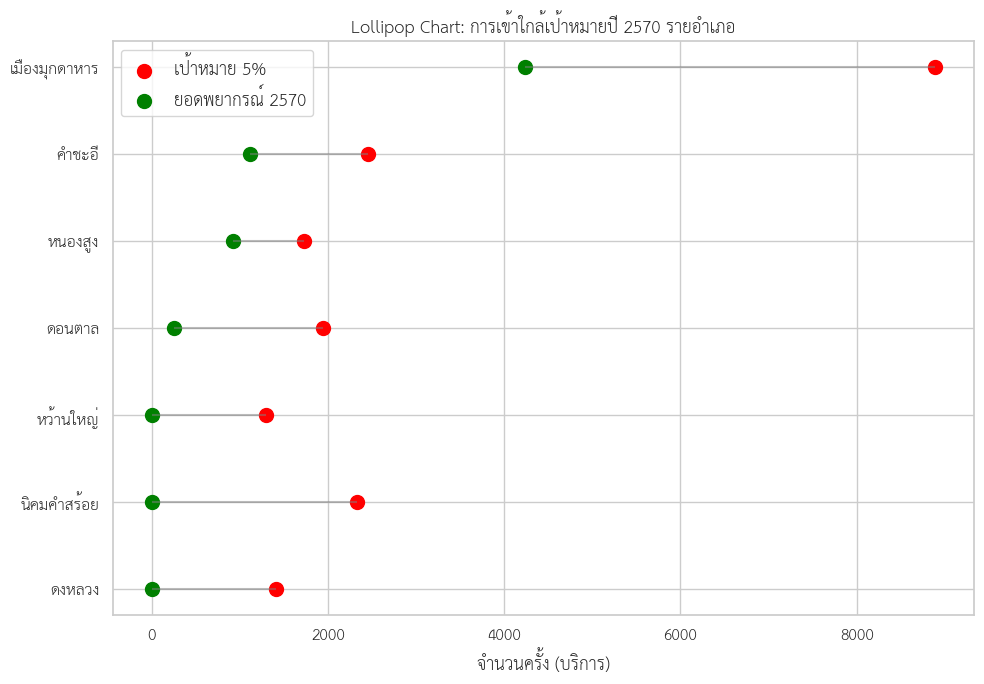

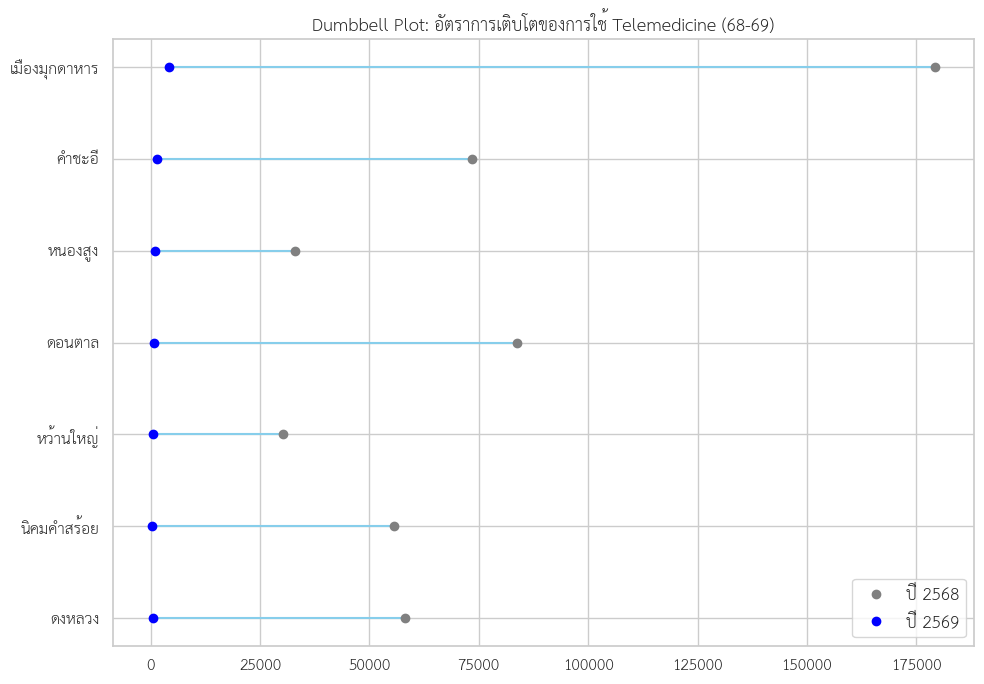

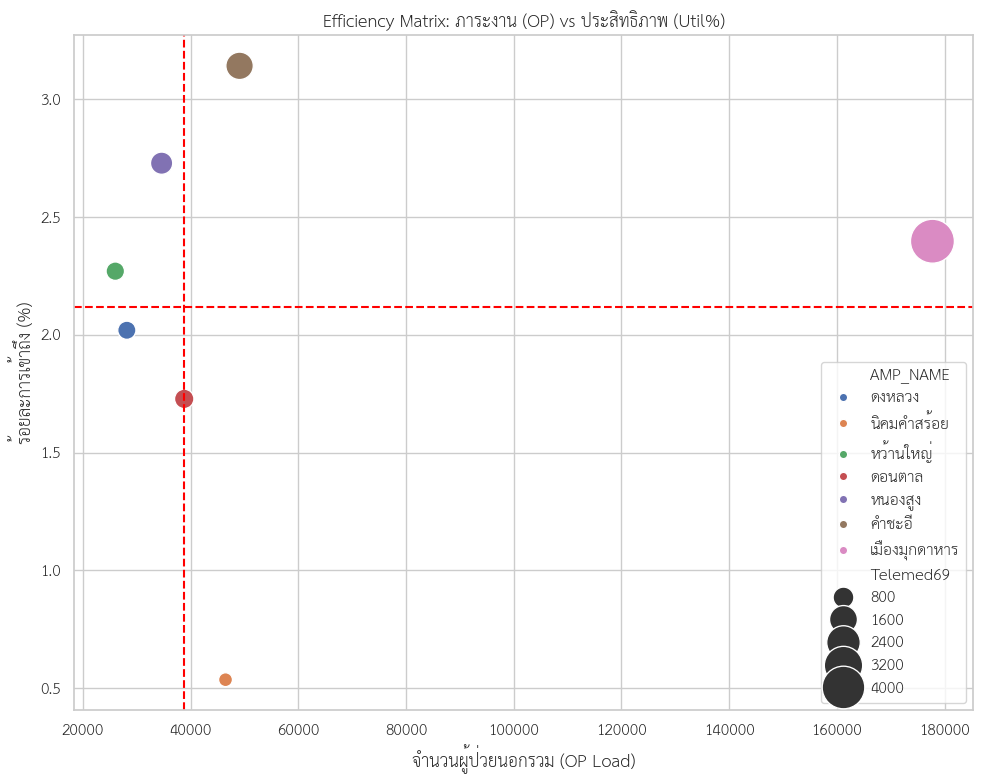

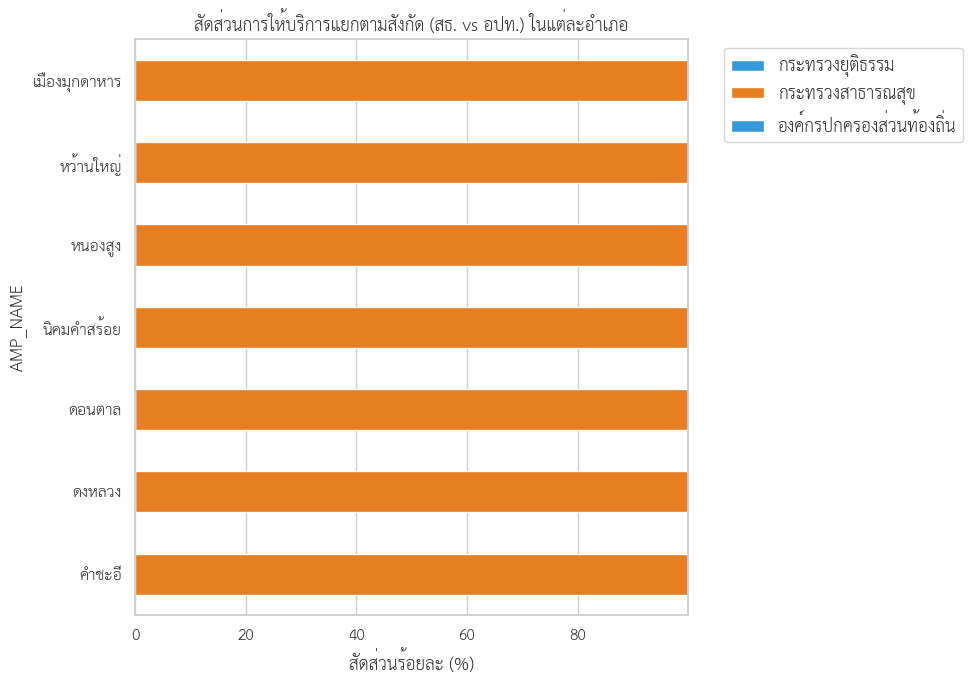

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. การตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดและเตรียมข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP68', 'Telemed68', 'OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# คำนวณ Metric สำคัญ
df['Forecast_2570'] = (df['Telemed69'] + (df['Telemed69'] - df['Telemed68'])).clip(lower=0)
df['Target_2570'] = (df['OP69'] * 0.05)
dist_data = df.groupby('AMP_NAME').agg({
    'Telemed68': 'sum',
    'Telemed69': 'sum',
    'OP69': 'sum',
    'Forecast_2570': 'sum',
    'Target_2570': 'sum'
}).reset_index()

# ---------------------------------------------------------
# รูปแบบที่ 1: Lollipop Chart (พยากรณ์ vs เป้าหมาย)
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))
dist_data = dist_data.sort_values(by='Forecast_2570')
plt.hlines(y=dist_data['AMP_NAME'], xmin=dist_data['Target_2570'], xmax=dist_data['Forecast_2570'], color='grey', alpha=0.5)
plt.scatter(dist_data['Target_2570'], dist_data['AMP_NAME'], color='red', label='เป้าหมาย 5%', s=100)
plt.scatter(dist_data['Forecast_2570'], dist_data['AMP_NAME'], color='green', label='ยอดพยากรณ์ 2570', s=100)
plt.title('Lollipop Chart: การเข้าใกล้เป้าหมายปี 2570 รายอำเภอ', fontsize=16, fontproperties=prop)
plt.legend(prop=prop)
plt.xlabel('จำนวนครั้ง (บริการ)', fontproperties=prop)
plt.tight_layout()
plt.savefig('chart_lollipop_target.png')

# ---------------------------------------------------------
# รูปแบบที่ 2: Dumbbell Plot (การเติบโต 68 -> 69)
# ---------------------------------------------------------
plt.figure(figsize=(10, 7))
plt.hlines(y=dist_data['AMP_NAME'], xmin=dist_data['Telemed68'], xmax=dist_data['Telemed69'], color='skyblue')
plt.plot(dist_data['Telemed68'], dist_data['AMP_NAME'], "o", color='grey', label='ปี 2568')
plt.plot(dist_data['Telemed69'], dist_data['AMP_NAME'], "o", color='blue', label='ปี 2569')
plt.title('Dumbbell Plot: อัตราการเติบโตของการใช้ Telemedicine (68-69)', fontsize=16, fontproperties=prop)
plt.legend(prop=prop)
plt.tight_layout()
plt.savefig('chart_dumbbell_growth.png')

# ---------------------------------------------------------
# รูปแบบที่ 3: Scatter Quadrant (Efficiency Matrix)
# ---------------------------------------------------------
dist_data['Util_Rate'] = (dist_data['Telemed69'] / dist_data['OP69'] * 100).fillna(0)
plt.figure(figsize=(10, 8))
sns.scatterplot(data=dist_data, x='OP69', y='Util_Rate', size='Telemed69', hue='AMP_NAME', sizes=(100, 1000))
plt.axhline(dist_data['Util_Rate'].mean(), color='red', linestyle='--')
plt.axvline(dist_data['OP69'].median(), color='red', linestyle='--')
plt.title('Efficiency Matrix: ภาระงาน (OP) vs ประสิทธิภาพ (Util%)', fontsize=16, fontproperties=prop)
plt.xlabel('จำนวนผู้ป่วยนอกรวม (OP Load)', fontproperties=prop)
plt.ylabel('ร้อยละการเข้าถึง (%)', fontproperties=prop)
plt.tight_layout()
plt.savefig('chart_quadrant_matrix.png')

# ---------------------------------------------------------
# รูปแบบที่ 4: Stacked Area / 100% Bar (Affiliation Share)
# ---------------------------------------------------------
aff_share = df.groupby(['AMP_NAME', 'M_NAME'])['Telemed69'].sum().unstack().fillna(0)
aff_share_pct = aff_share.div(aff_share.sum(axis=1), axis=0) * 100
ax = aff_share_pct.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#3498db', '#e67e22'])
plt.title('สัดส่วนการให้บริการแยกตามสังกัด (สธ. vs อปท.) ในแต่ละอำเภอ', fontsize=16, fontproperties=prop)
plt.xlabel('สัดส่วนร้อยละ (%)', fontproperties=prop)
plt.legend(prop=prop, bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('chart_affiliation_share.png')

print("✅ สร้างกราฟทั้ง 4 รูปแบบเรียบร้อยแล้ว!")

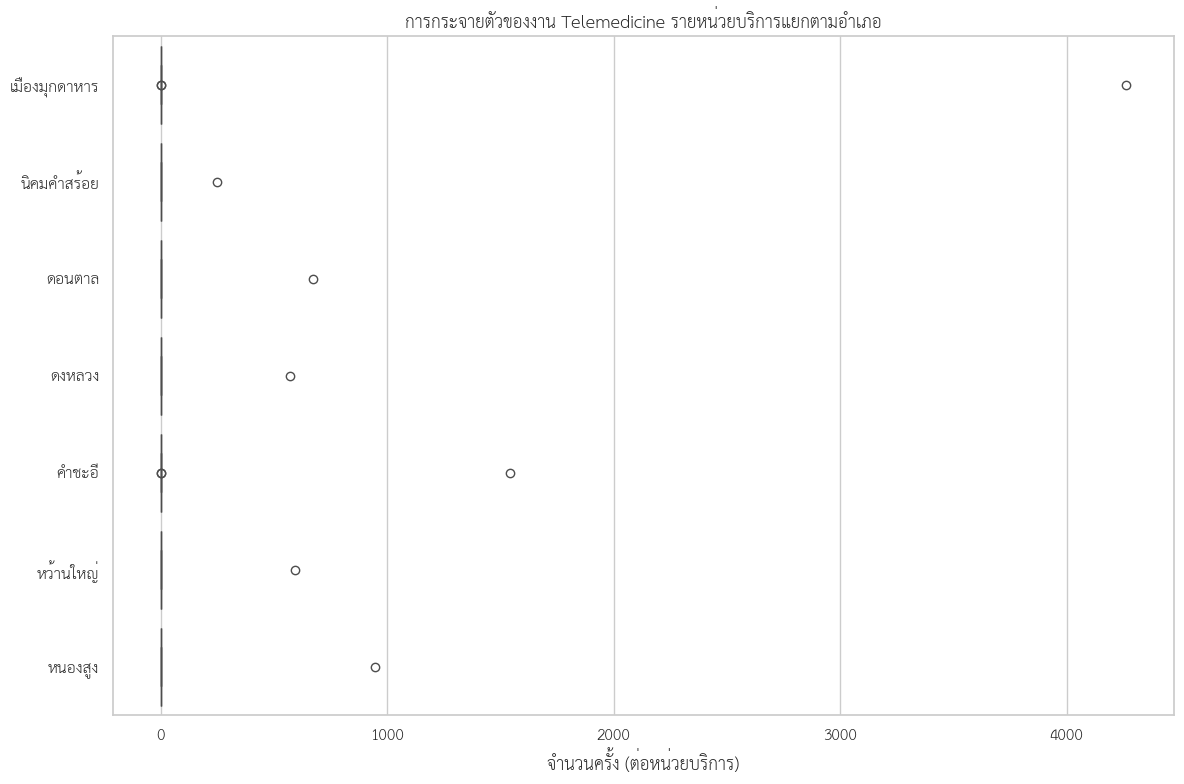

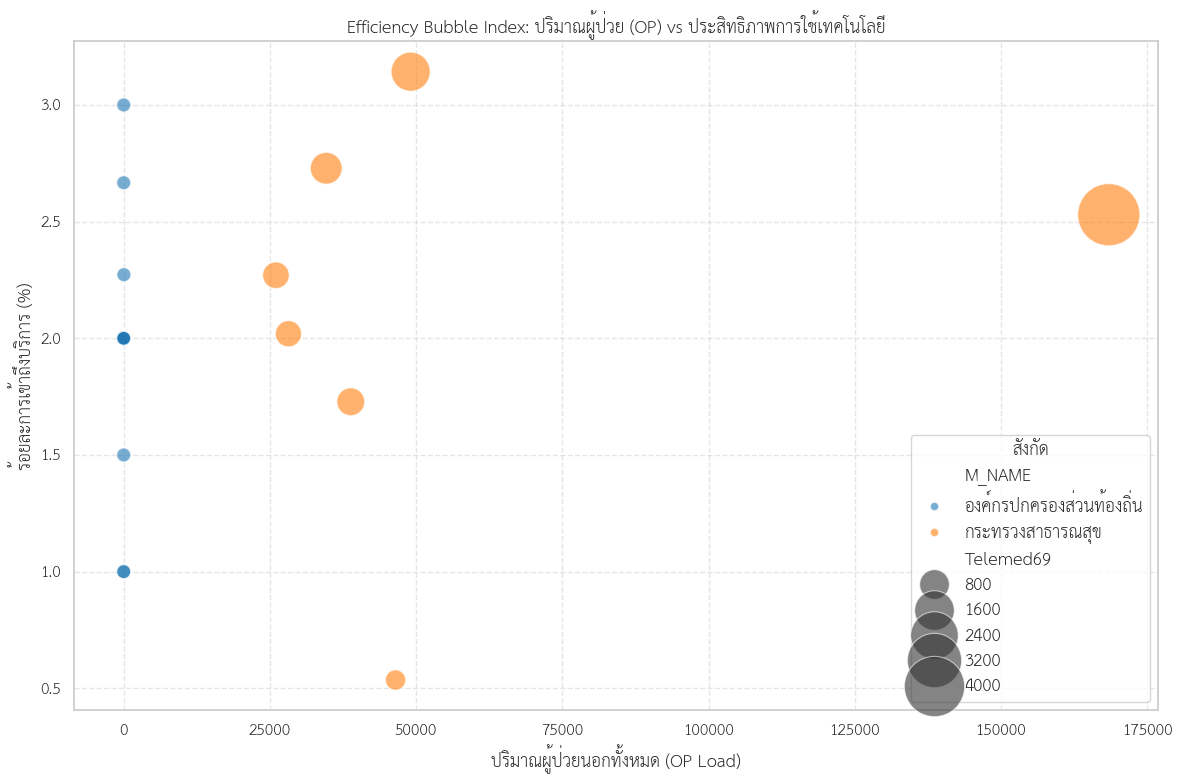

📋 รายงานความตื่นตัวระดับหน่วยบริการแยกตามสังกัด:
                  สังกัด  จำนวนหน่วยงานทั้งหมด  จำนวนหน่วยงานที่เริ่มทำแล้ว  อัตราการตื่นตัว (%)
         กระทรวงยุติธรรม                     1                            0                  0.0
        กระทรวงสาธารณสุข                     7                            7                100.0
องค์กรปกครองส่วนท้องถิ่น                    78                           11                 14.1


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# --- 1. ตั้งค่าฟอนต์ภาษาไทย ---
font_path = '/home/jovyan/work/_ShareInProvince/visualization/thsarabunnew.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams['font.family'] = font_name
    prop = fm.FontProperties(fname=font_path)
else:
    font_name = 'sans-serif'
    prop = None

# --- 2. โหลดข้อมูล ---
df = pd.read_csv('telemed_hosp_final.csv')
for col in ['OP69', 'Telemed69']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ---------------------------------------------------------
# รูปแบบที่ 1: Box Plot (ความสม่ำเสมอภายในเครือข่ายอำเภอ)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid", font=font_name)
# ใช้ log scale ถ้าข้อมูลมีความต่างกันมาก (เช่น รพ.มุกดาหาร แบกเยอะเกินไป)
ax = sns.boxplot(data=df, x='Telemed69', y='AMP_NAME', palette='light:#5A9', hue='AMP_NAME', legend=False)
plt.title('การกระจายตัวของงาน Telemedicine รายหน่วยบริการแยกตามอำเภอ', fontsize=18, fontproperties=prop)
plt.xlabel('จำนวนครั้ง (ต่อหน่วยบริการ)', fontproperties=prop)
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart_box_variation.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# รูปแบบที่ 2: Bubble Chart (ประสิทธิภาพเทียบกับปริมาณงาน)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
df['Util_Rate'] = (df['Telemed69'] / df['OP69'] * 100).fillna(0)
# กรองเฉพาะหน่วยงานที่เริ่มทำแล้ว
active_df = df[df['Telemed69'] > 0]
sns.scatterplot(data=active_df, x='OP69', y='Util_Rate', size='Telemed69', hue='M_NAME', 
                alpha=0.6, sizes=(100, 2000), palette=['#1f77b4', '#ff7f0e'])

plt.title('Efficiency Bubble Index: ปริมาณผู้ป่วย (OP) vs ประสิทธิภาพการใช้เทคโนโลยี', fontsize=18, fontproperties=prop)
plt.xlabel('ปริมาณผู้ป่วยนอกทั้งหมด (OP Load)', fontproperties=prop)
plt.ylabel('ร้อยละการเข้าถึงบริการ (%)', fontproperties=prop)
plt.legend(prop=prop, title='สังกัด')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('chart_bubble_efficiency.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# รูปแบบที่ 3: สรุปตาราง "ความคุ้มค่าของชุดอุปกรณ์" (Unit Productivity)
# ---------------------------------------------------------
# คำนวณว่าแต่ละสังกัด มีหน่วยงานที่ "Active" (ทำจริง) คิดเป็นกี่เปอร์เซ็นต์
unit_summary = df.groupby('M_NAME').agg({
    'hospcode': 'count',
    'Telemed69': lambda x: (x > 0).sum()
}).reset_index()
unit_summary.columns = ['สังกัด', 'จำนวนหน่วยงานทั้งหมด', 'จำนวนหน่วยงานที่เริ่มทำแล้ว']
unit_summary['อัตราการตื่นตัว (%)'] = (unit_summary['จำนวนหน่วยงานที่เริ่มทำแล้ว'] / unit_summary['จำนวนหน่วยงานทั้งหมด'] * 100).round(2)

print("📋 รายงานความตื่นตัวระดับหน่วยบริการแยกตามสังกัด:")
print(unit_summary.to_string(index=False))

In [55]:
hdc.close()